In [2]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
base_folder = 'DataScience'
location_base = os.path.join(os.getcwd().split(base_folder)[0], base_folder)
location_module = [os.path.join(location_base, 'Module')] 
for each in location_module:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

from import_KK import *
# DeviceStrategy_CPU()
DeviceStrategy_GPU()
from preprocessing_KK import *
from preprocessing_project_KK import *
from description_KK import *
from algorithm_machinelearning_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *
from visualization_KK import *


=========== GPU Strategy ===========
Detected GPUs:
 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TF using MirroredStrategy with 2 GPUs:
 ['/GPU:0', '/GPU:1']


======= GPU / CUDA / STATUS ========
Cuda Ready?        True
CUDA Version:      12.5.1
cuDNN Version:     9

TF Version:        2.19.0
Keras Version:     3.10.0
True
Torch Version:       2.7.1+cu126
Torch CUDA Version:  12.6
Torch cuDNN Version: 90501

Torch GPUs Available: 2
Use the GPU: NVIDIA GeForce RTX 3090



# Hyperparameters

In [3]:
# Data
# FOLDER_GDM, FOLDER_GDS = get_google_drivelocation(gdrive='z', glocation=os.path.join('Research', 'SavedData', 'MDIS-SocialSurvey'))
# FOLDER_LOCATION = FOLDER_GDM
FILENAME = 'processed_data_2019_2023_union_.csv'
# FILE_LOCATION = os.path.join(FOLDER_LOCATION, FILENAME)
FILE_LOCATION = os.path.join('.', 'Data', FILENAME)
LANGUAGE = 'kr'

# Preprocessing
Y_colname = '사업운영계획'
X_reverse = None
X_nullmax = None
X_nullmin = None
X_dummy = None
X_encoding = None
X_delYrelated = None
X_delete = None

TEST_SIZE = 0.3
YEAR_VAL, YEAR_TEST = 1, 1 # Execute when TEST_SIZE = 'Time'
RANDOM_STATE = 123
CLASS_STAT = True
## 'RandomUnderSampler' <<< 'TomekLinks' << 'CondensedNearestNeighbour' < 'OneSidedSelection'
## 'SMOTE' <<< 'SMOTETomek' << 'BorderlineSMOTE' < 'ADASYN', 'auto'
# SAMPLING_METHOD = 'ADASYN'
SAMPLING_METHOD = 'auto'
## 'minority', 'not majority', 'not minority', 'all', 'auto'
SAMPLING_STRATEGY = 'auto'    # 'minority', 'not majority', 'not minority', 'all', 'auto'
SCALER = 'minmax'
LABEL_LIST = ['Non-operation', 'Operation']

# Model
## Common
TUNE_TRIALS_ML = 10
TUNE_TRIALS_DL = 10
CV_SPLITS = 5
## ML
TUNE_METRIC = 'F1-score' # Default('auto'): 'F1-score', 'RMSE' - 접두사 없어도 자동으로 validation set 기준으로 판단
## DL
tf.random.set_seed(123)
NODE_MLP = [128, 256, 128, 64, 32, 10]
NODE_CNN = [32, 64, 128]
VALIDATION_SPLIT = 0.2
if VALIDATION_SPLIT != None:
    VALIDATION_DATA = None
BATCH_SIZE = 64
EPOCHS = 100
VERBOSE = 0
TUNE_METRIC_DL = 'val_F1-score' # 'AUC', 'Accuracy', 'F1-score', 'loss', 'val_AUC', 'val_Accuracy', 'val_F1-score', 'val_loss'
## Final + XAI
METRIC_FINAL = "F1-score"
SHAP = True
INTERACTION = True
INTERACTION_SAMPLES = 2000
# FEATURE_PERTURBATION = 'tree_path_dependent'    # 'tree_path_dependent', 'interventional'
X_TOP_DISPLAY = 50

# Save
SAVE_NAME_PREDSTATTR = 'DescriptiveStatistics_BinaryPredTrain.csv'
SAVE_NAME_PREDSTATTE = 'DescriptiveStatistics_BinaryPredTest.csv'
SAVE_NAME_ML = 'Performance_ML'
SAVE_NAME_DL = 'Performance_DL'
SAVE_NAME_PERFORMANCE = 'Performance.csv'

# Data

In [4]:
# Solution
def preprocessing_KTY(
    df_raw, 
    Y_colname='Y',
    X_dummy=None, X_delete=None,
    test_size=0.2, year_val=1, year_test=1, 
    cv_splits=5,
    class_stat=True,
    sampling_method=None, sampling_strategy='auto',
    scaler='minmax', random_state=123,
    label_list=['0', '1'], language='kr'
):
    df = df_raw.copy()
    print('\nPreprocessing for Data Prepare...')
    print('Initial Shape: ', df.shape)
    
    # 결측치 처리
    print('\nPreprocessing NAN...')
    df_X = null_filling(df[[i for i in df.columns if i != Y_colname]], 
    delcol_nullratio=0.5, delrow_nullratio=None, fill_method='newlabel')
    df = pd.concat([df[Y_colname], df_X], axis=1)
    print('Shape: ', df.shape)
    
    # 불필요 변수 삭제
    if X_delete != None:
        print('\nDeleting Non-meaning Variables...')
        df = feature_drop(df, col_target=X_delete)
        print('Shape: ', df.shape)
    
    # 더미변수 생성
    if X_dummy != None:
        df = feature_categ_DummyVariable(df, target=X_dummy)
    print('Shape: ', df.shape)
    
    # 독립변수 설정
    X_colname = [x for x in df.columns if x != Y_colname]
    
    # Train, Test 분리 및 검증
    print('\nSplitting Data...')
    
    # 1. 분할 로직 (OOT vs Random)
    if test_size == 'Time':
        # Time-based (OOT) 분할: 시간순 배열 가정, 섞지 않음 (Shuffle=False)
        # 80:20 비율로 하드코딩된 예시이며, 필요시 파라미터로 조절 가능합니다.
        split_idx = int(len(df) * 0.8) 
        X_train = df[X_colname].iloc[:split_idx]
        X_test  = df[X_colname].iloc[split_idx:]
        Y_train = df[[Y_colname]].iloc[:split_idx]
        Y_test  = df[[Y_colname]].iloc[split_idx:]
        print("▷ Time-based Split Applied (Shuffle=False)")
    else:
        # Random 분할: 층화 추출(stratify) 강제 적용
        from sklearn.model_selection import train_test_split
        X_train, X_test, Y_train, Y_test = train_test_split(
            df[X_colname], df[[Y_colname]],
            test_size=float(test_size), 
            stratify=df[Y_colname], 
            random_state=random_state
        )
        print("▷ Random Split with Stratification Applied")

    # 2. 분할 검증 (Data Split Check)
    # 원본, Train, Test의 클래스 비율이 동일하게(예: 0.1 vs 0.9) 유지되었는지 콘솔에 출력합니다.
    print("\n[Data Split Check - Target Ratio]")
    print("1. Total Data:")
    print(df[Y_colname].value_counts(normalize=True).round(4).to_string())
    print("\n2. Train Set:")
    print(Y_train.value_counts(normalize=True).round(4).to_string())
    print("\n3. Test Set:")
    print(Y_test.value_counts(normalize=True).round(4).to_string())
    print("-" * 50)
    # ----------------------------------------------------------------
    
    # 샘플링
    if sampling_method != None:
        if sampling_method in ['RandomUnderSampler', 'TomekLinks', 'CondensedNearestNeighbour', 'OneSidedSelection']:
            print('Undersampling...')
            sampler, X_train, Y_train = undersampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)   
        elif sampling_method in ['SMOTE', 'SMOTETomek', 'BorderlineSMOTE', 'ADASYN']:
            print('Oversampling...')
            sampler, X_train, Y_train = oversampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)  
        elif sampling_method == 'auto':
            if df[Y_colname].value_counts().sort_values(ascending=False).index[0] == 0:
                print('Undersampling...')
                sampling_method = 'RandomUnderSampler'
                sampler, X_train, Y_train = undersampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)   
            else:
                print('Oversampling...')
                sampling_method = 'ADASYN'
                sampler, X_train, Y_train = oversampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)   

    # Optuna 튜닝용 OOT 인덱스 추출
    cv_splits = cv_splits
    if test_size == 'Time':
        if isinstance(X_train, pd.DataFrame):
            train_idx = np.where(X_train[dynamic_year_col] < val_threshold)[0].tolist()
            val_idx = np.where(X_train[dynamic_year_col] >= val_threshold)[0].tolist()
        else:
            year_idx = X_colname.index(dynamic_year_col)
            train_idx = np.where(X_train[:, year_idx] < val_threshold)[0].tolist()
            val_idx = np.where(X_train[:, year_idx] >= val_threshold)[0].tolist()
        cv_splits = (train_idx, val_idx)
        print(f"   ▷ [Generated CV Tuple] Train Index: {len(train_idx)}, Val Index: {len(val_idx)}")
    
    # 스케일링
    print('\nPreprocessing of Scaling...')
    scaler_dict = {}
    
    # 샘플링(SMOTE 등) 후 데이터가 DataFrame 혹은 Numpy Array일 수 있으므로 포맷 통일
    X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
    X_test_np = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
    
    # 결과를 담을 빈 배열 생성
    X_train_scaled = np.zeros_like(X_train_np, dtype=float)
    X_test_scaled = np.zeros_like(X_test_np, dtype=float)
    
    for i, col in enumerate(X_colname):
        from sklearn.preprocessing import MinMaxScaler, StandardScaler
        # 조건에 맞는 스케일러 할당 (향후 확장을 위해)
        s = MinMaxScaler() if scaler == 'minmax' else StandardScaler()
        
        # 각 변수별로 2D 배열 추출
        train_col = X_train_np[:, i].reshape(-1, 1)
        test_col = X_test_np[:, i].reshape(-1, 1)
        
        # 변수별 스케일링 및 스케일러 객체를 딕셔너리에 저장
        X_train_scaled[:, i] = s.fit_transform(train_col).flatten()
        X_test_scaled[:, i] = s.transform(test_col).flatten()
        scaler_dict[col] = s
        
    X_train = X_train_scaled
    X_test = X_test_scaled
    print(X_train.shape, Y_train.shape, X_train.min(), X_train.max())
    print(X_test.shape, Y_test.shape, X_test.min(), X_test.max())    
    
    print('Complete!')
    
    # 반환값 마지막에 scaler_dict 추가
    return X_train, X_test, Y_train, Y_test, df, X_colname, scaler_dict, cv_splits

df_raw = pd.read_csv(FILE_LOCATION, encoding='utf-8-sig')
# 전처리
X_train, X_test, Y_train, Y_test, df_prep, X_colname, scaler, CV_SPLITS = preprocessing_KTY(
    df_raw, 
    Y_colname=Y_colname,
    X_dummy=X_dummy, X_delete=X_delete,
    test_size=TEST_SIZE, 
    year_val=YEAR_VAL, year_test=YEAR_TEST,
    cv_splits=CV_SPLITS,
    sampling_method=SAMPLING_METHOD,
    sampling_strategy=SAMPLING_STRATEGY,
    scaler=SCALER,
    label_list=LABEL_LIST,
    language=LANGUAGE,
)


Preprocessing for Data Prepare...
Initial Shape:  (88387, 82)

Preprocessing NAN...
Column Deleting...
These  28.39506172839506 %( 23 ) columns are containing more than  50.0 % null values!: ['경영애로사항_10', '코로나19지원정책_1', '코로나19지원정책_2', '코로나19지원정책_3', '코로나19지원정책_4', '코로나19지원정책_5', '코로나19지원정책_6', '코로나19지원정책_7', '코로나19지원정책_8', '코로나19지원정책_응답여부', '재난지원_1', '재난지원_2', '재난지원_3', '재난지원_4', '재난지원_5', '재난지원_6', '재난지원_7', '재난지원_8', '재난지원_응답여부', '디지털대응_7', '디지털대응_8', '디지털대응_9', '디지털대응_도입여부']

These  0 columns are containing just 1 unique value!: []

Row Deleting...

Filling Null Values...


  0%|          | 0/8 [00:00<?, ?it/s]


Shape of Data:  (88387, 58)
Complete of fillna!
Shape:  (88387, 59)
Shape:  (88387, 59)

Splitting Data...
▷ Random Split with Stratification Applied

[Data Split Check - Target Ratio]
1. Total Data:
사업운영계획
1   0.8939
0   0.1061

2. Train Set:
사업운영계획
1        0.8939
0        0.1061

3. Test Set:
사업운영계획
1        0.8938
0        0.1062
--------------------------------------------------
Oversampling...
(61870, 58) (61870, 1)
Ratio of Origin Y:  사업운영계획
1         55303
0          6567
Name: count, dtype: int64
(112151, 58) (112151, 1)
Ratio of Sampling Y:  사업운영계획
0         56848
1         55303
Name: count, dtype: int64

Preprocessing of Scaling...
(112151, 58) (112151, 1) 0.0 1.0
(26517, 58) (26517, 1) 0.0 1.1016340148857902
Complete!


# Modeling

## Machine Learning

▶ Detected Task Type: [ classification ] (Target: binary)

   Running Machine Learning Algorithm: Logistic Regression (classification)
Learning...:  2026-05-28 13:51:52.474795


  0%|          | 0/10 [00:00<?, ?it/s]

[Logistic Regression] Best Optuna Score (F1-score):  0.9365346604636937
[Logistic Regression] Best Tuning Parameters:  {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.06912859450123959, 'class_weight': None, 'max_iter': 710, 'random_state': 123}

Explanations...:  2026-05-28 13:53:49.678209
Explanations of Y:


,Features,Coef,Features,Coef
0,직전종사상지위_2,4.5235,디지털대응_2,-1.1960
1,직전종사상지위_1,4.3958,디지털대응_6,-1.1198
2,직전종사상지위_3,4.3137,디지털대응_4,-0.4835
3,정부지원경험_1,4.2644,디지털대응_1,-0.4281
4,직전종사상지위_4,4.2412,창업과정어려움_업종선택,-0.4121
5,정부지원경험_2,4.1783,창업과정어려움_경영방법,-0.3917
6,정부지원경험_3,4.1420,디지털대응_5,-0.2516
7,창업동기_4,4.1120,창업준비활동중요성_시장조사,-0.1077
8,창업동기_2,4.0906,프랜차이즈가맹점여부,-0.0516
9,창업동기_3,4.0504,디지털대응_3,-0.0347


Performance Evaluations...:  2026-05-28 13:53:49.686528
Performance: 


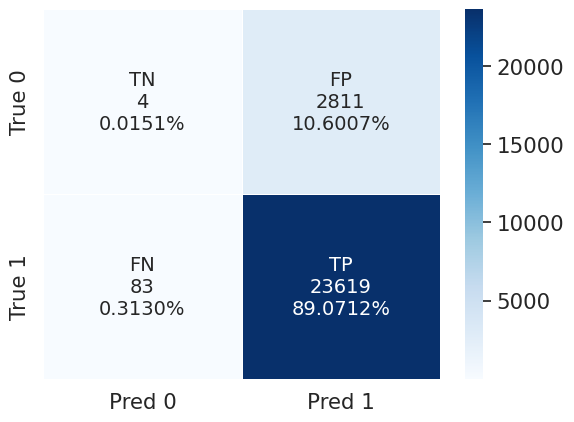

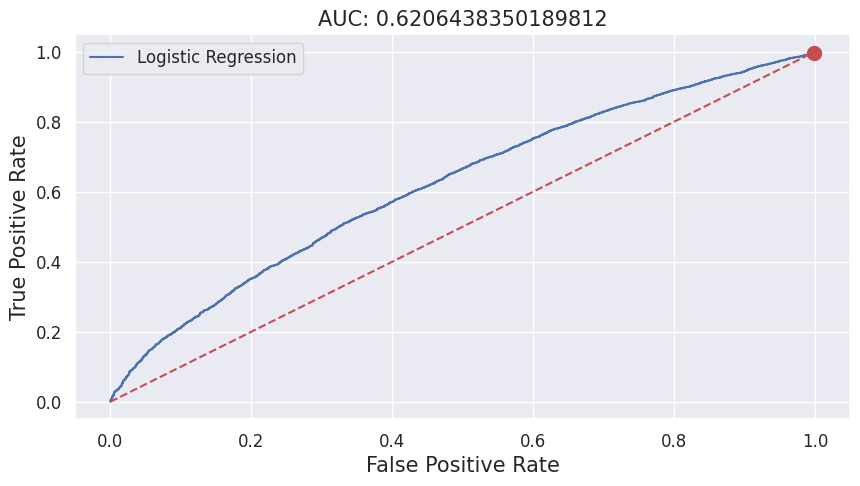

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,Train set,112151,55118,49561,7287,185,0.8832,0.9967,0.8718,0.9365,0.9334,0.9342,0.9540
1,Logistic Regression,Validation(CV),112151,55149,49544,7304,154,0.8832,0.9967,0.8718,0.9365,0.9334,0.9342,0.9534
2,Logistic Regression,Test set,26517,23619,4,2811,83,0.8936,0.9965,0.0014,0.9423,0.8909,0.4990,0.6206
3,Logistic Regression,Entire population,138668,78737,49565,10098,268,0.8863,0.9966,0.8307,0.9382,0.9252,0.9137,0.9383


   [Save] Logistic Regression Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_model_Logistic Regression_20260528_135411.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_params_Logistic Regression_20260528_135411.json

   Running Machine Learning Algorithm: Random Forest (classification)
Learning...:  2026-05-28 13:54:11.744206


  0%|          | 0/10 [00:00<?, ?it/s]

[Random Forest] Best Optuna Score (F1-score):  0.943223832348796
[Random Forest] Best Tuning Parameters:  {'n_estimators': 350, 'max_depth': None, 'max_features': 0.7154204740681307, 'min_samples_split': 11, 'min_samples_leaf': 6, 'bootstrap': False, 'random_state': 123, 'n_jobs': -1, 'class_weight': 'balanced'}

Explanations...:  2026-05-28 14:00:41.776901
Explanations of Y:


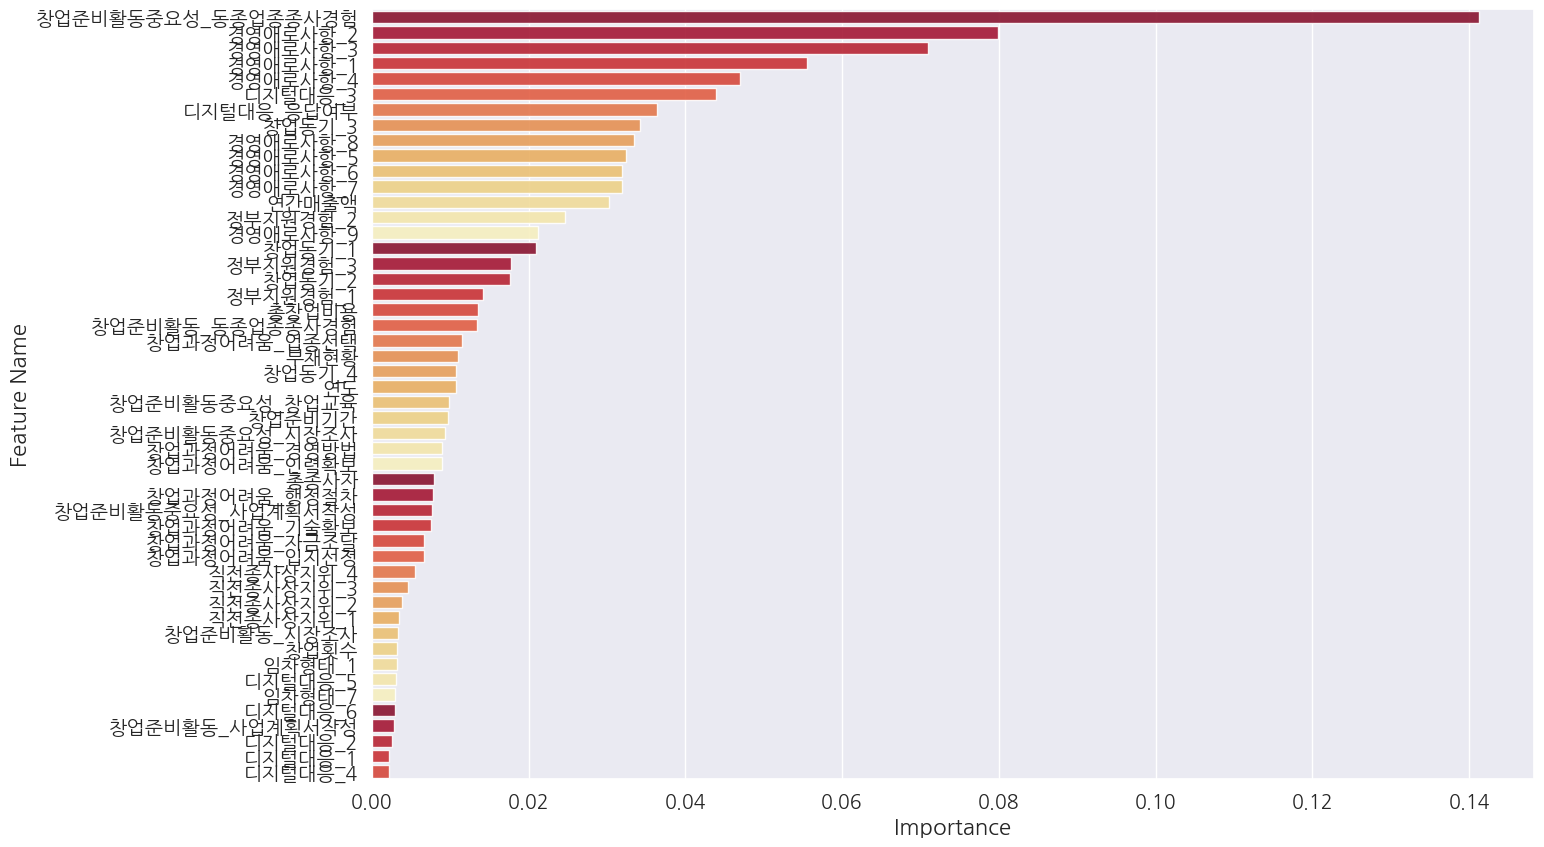

Performance Evaluations...:  2026-05-28 14:00:42.395908
Performance: 


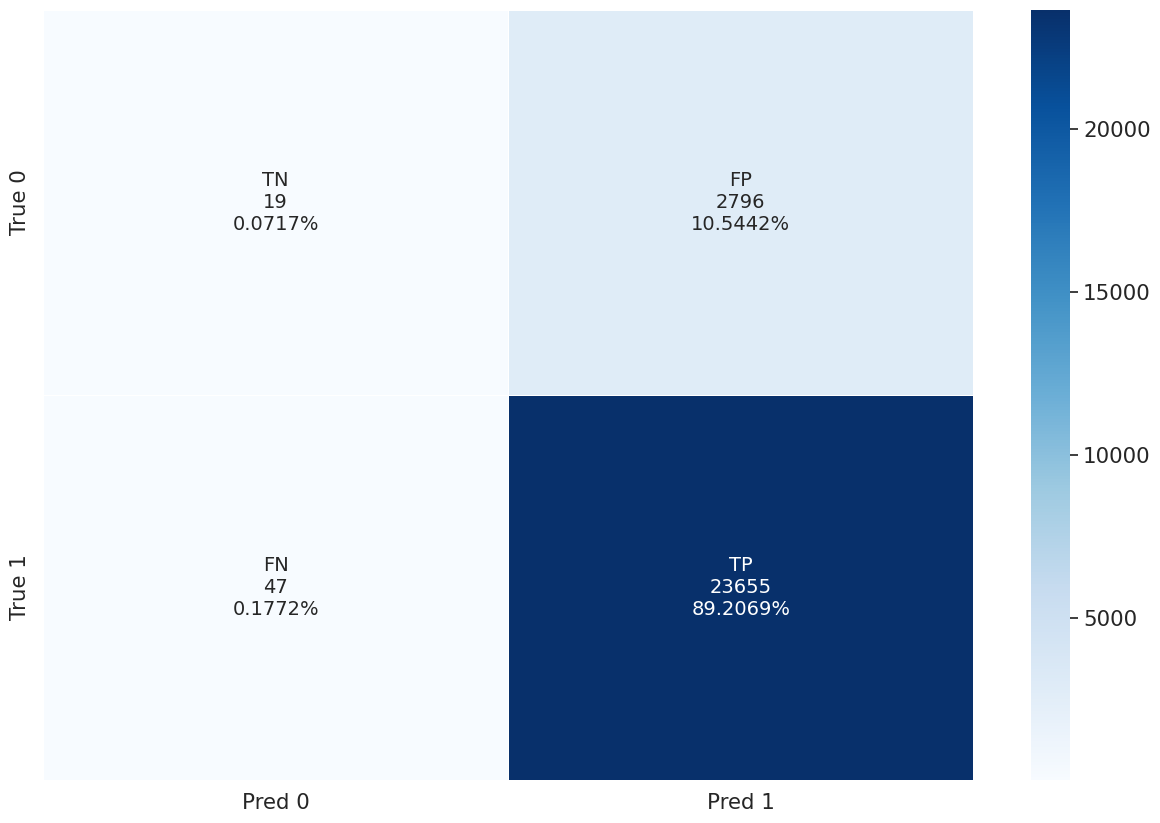

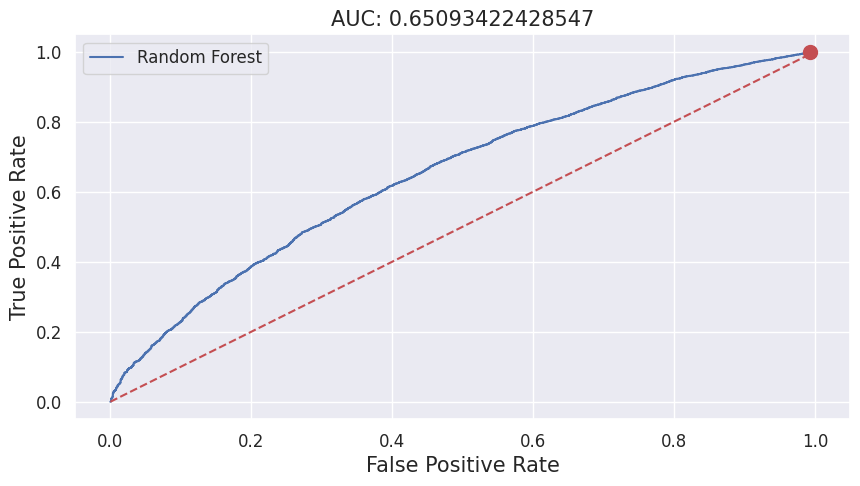

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Random Forest,Train set,112151,55303,52914,3934,0,0.9336,1.0000,0.9308,0.9657,0.9649,0.9654,1.0000
1,Random Forest,Validation(CV),112151,55144,50066,6782,159,0.8941,0.9980,0.8850,0.9432,0.9407,0.9415,0.9642
2,Random Forest,Test set,26517,23655,19,2796,47,0.8943,0.9980,0.0067,0.9433,0.8928,0.5024,0.6509
3,Random Forest,Entire population,138668,78958,52933,6730,47,0.9215,0.9994,0.8872,0.9589,0.9511,0.9433,0.9888


   [Save] Random Forest Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_model_Random Forest_20260528_140154.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_params_Random Forest_20260528_140154.json

   Running Machine Learning Algorithm: XGBoost (classification)
Learning...:  2026-05-28 14:01:56.785078


  0%|          | 0/10 [00:00<?, ?it/s]

[XGBoost] Best Optuna Score (F1-score):  0.9435585922200834
[XGBoost] Best Tuning Parameters:  {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.09566714808673339, 'subsample': 0.8714378292230818, 'colsample_bytree': 0.7843387723502073, 'min_child_weight': 1.776028635636206, 'gamma': 2.278758629733832, 'reg_alpha': 0.0012598330106616366, 'reg_lambda': 0.02220019390627171, 'random_state': 123, 'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0, 'scale_pos_weight': 4.027661899492237}

Explanations...:  2026-05-28 14:03:04.447852
Explanations of Y:


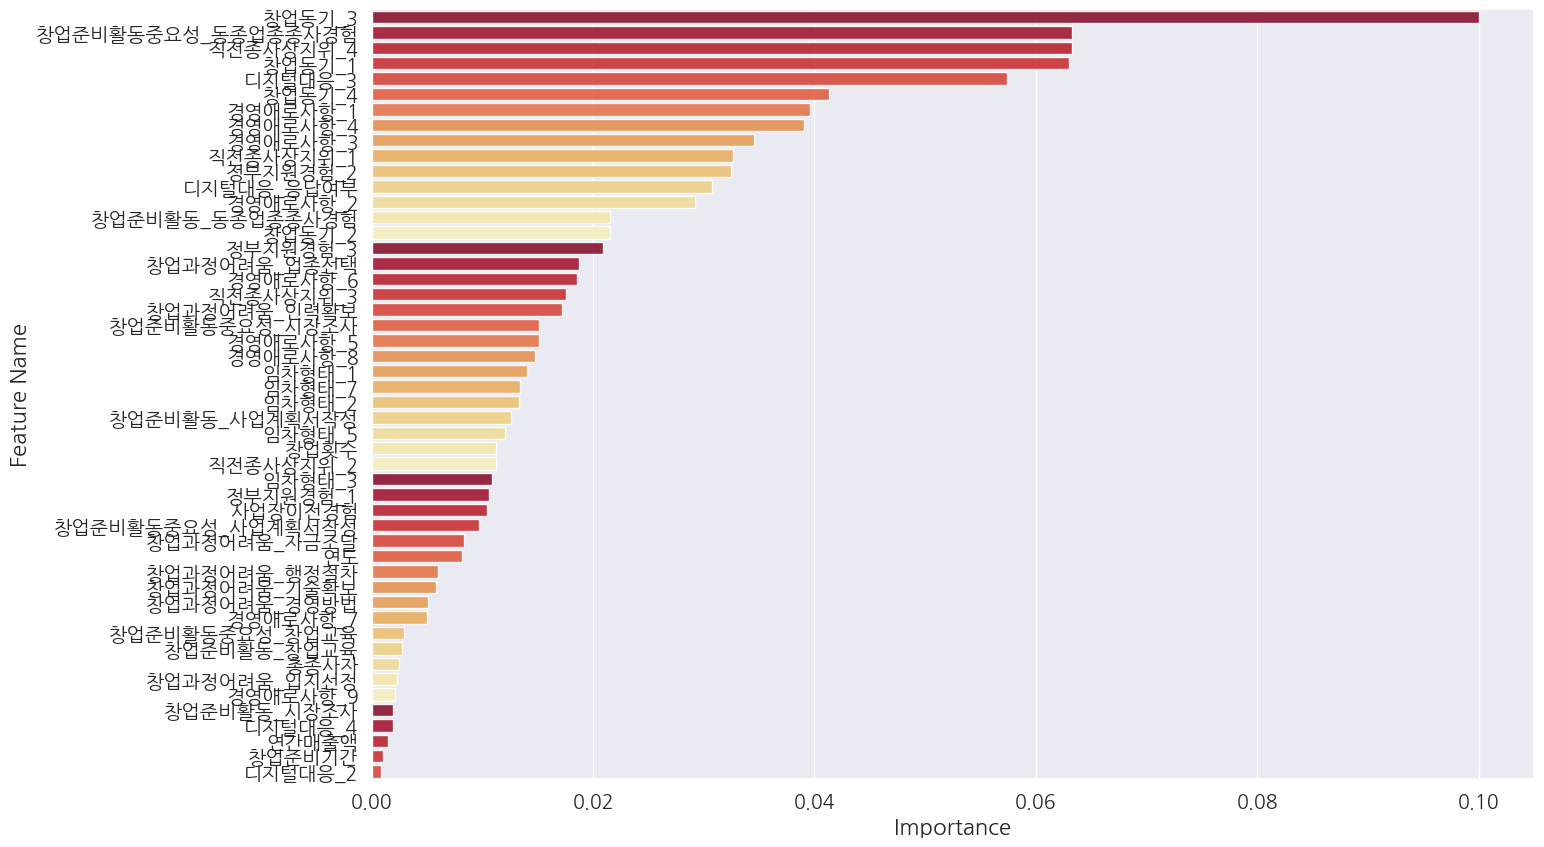

Performance Evaluations...:  2026-05-28 14:03:04.972875
Performance: 


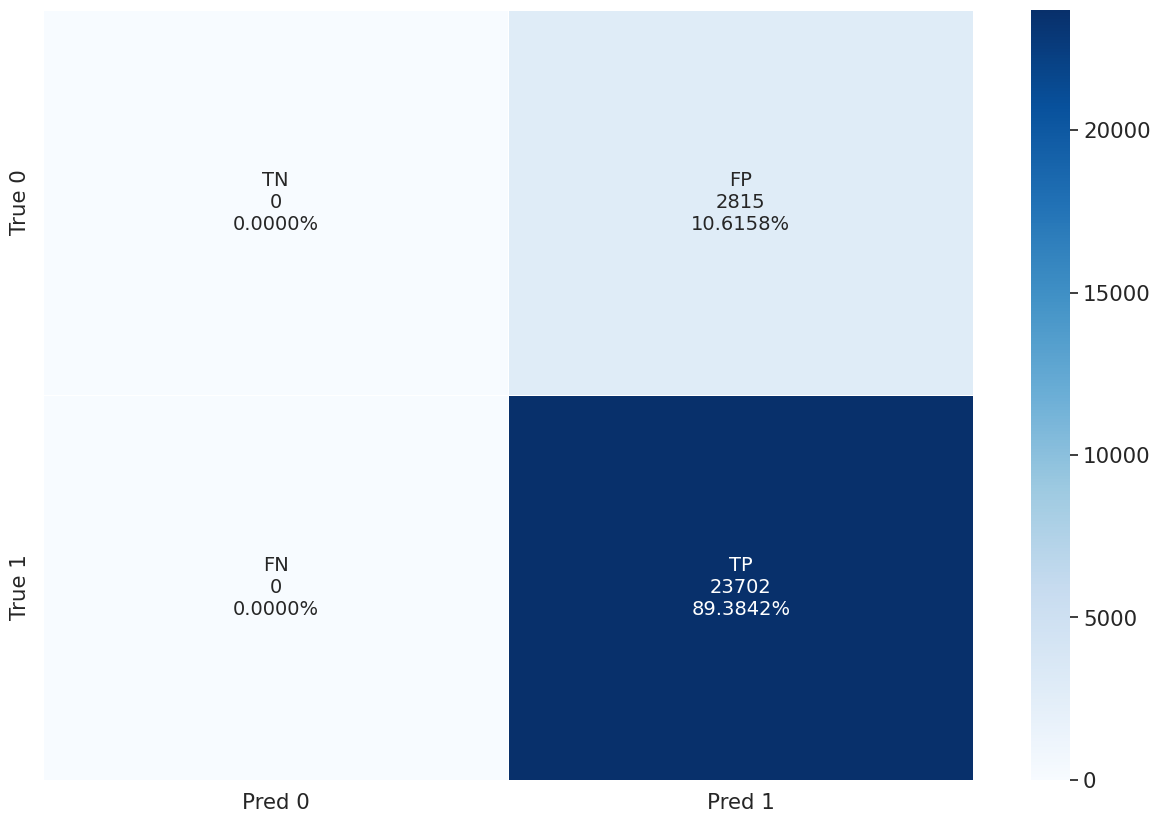

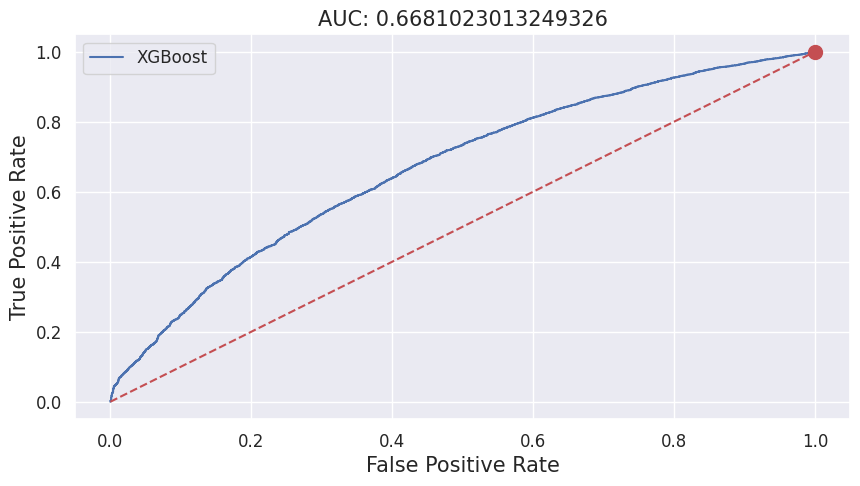

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,Train set,112151,55303,50285,6563,0,0.8939,1.0000,0.8846,0.9440,0.9415,0.9423,0.9771
1,XGBoost,Validation(CV),112151,55296,50227,6621,7,0.8932,0.9999,0.8837,0.9436,0.9410,0.9418,0.9628
2,XGBoost,Test set,26517,23702,0,2815,0,0.8938,1.0000,0.0000,0.9439,0.8938,0.5000,0.6681
3,XGBoost,Entire population,138668,79005,50285,9378,0,0.8939,1.0000,0.8428,0.9440,0.9324,0.9214,0.9626


   [Save] XGBoost Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_model_XGBoost_20260528_140311.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_params_XGBoost_20260528_140311.json

   Running Machine Learning Algorithm: LightGBM (classification)
Learning...:  2026-05-28 14:03:11.233702


  0%|          | 0/10 [00:00<?, ?it/s]

[LightGBM] Best Optuna Score (F1-score):  0.9438876008980328
[LightGBM] Best Tuning Parameters:  {'n_estimators': 950, 'learning_rate': 0.015822105802552375, 'num_leaves': 50, 'max_depth': 11, 'min_child_samples': 30, 'subsample': 0.7180267315381805, 'colsample_bytree': 0.5825936023754742, 'min_split_gain': 0.3017889207716401, 'extra_trees': False, 'reg_alpha': 0.005534911984995076, 'reg_lambda': 1.3884977590764778, 'random_state': 123, 'n_jobs': -1, 'verbose': -1, 'class_weight': None}

Explanations...:  2026-05-28 14:09:07.696724
Explanations of Y:


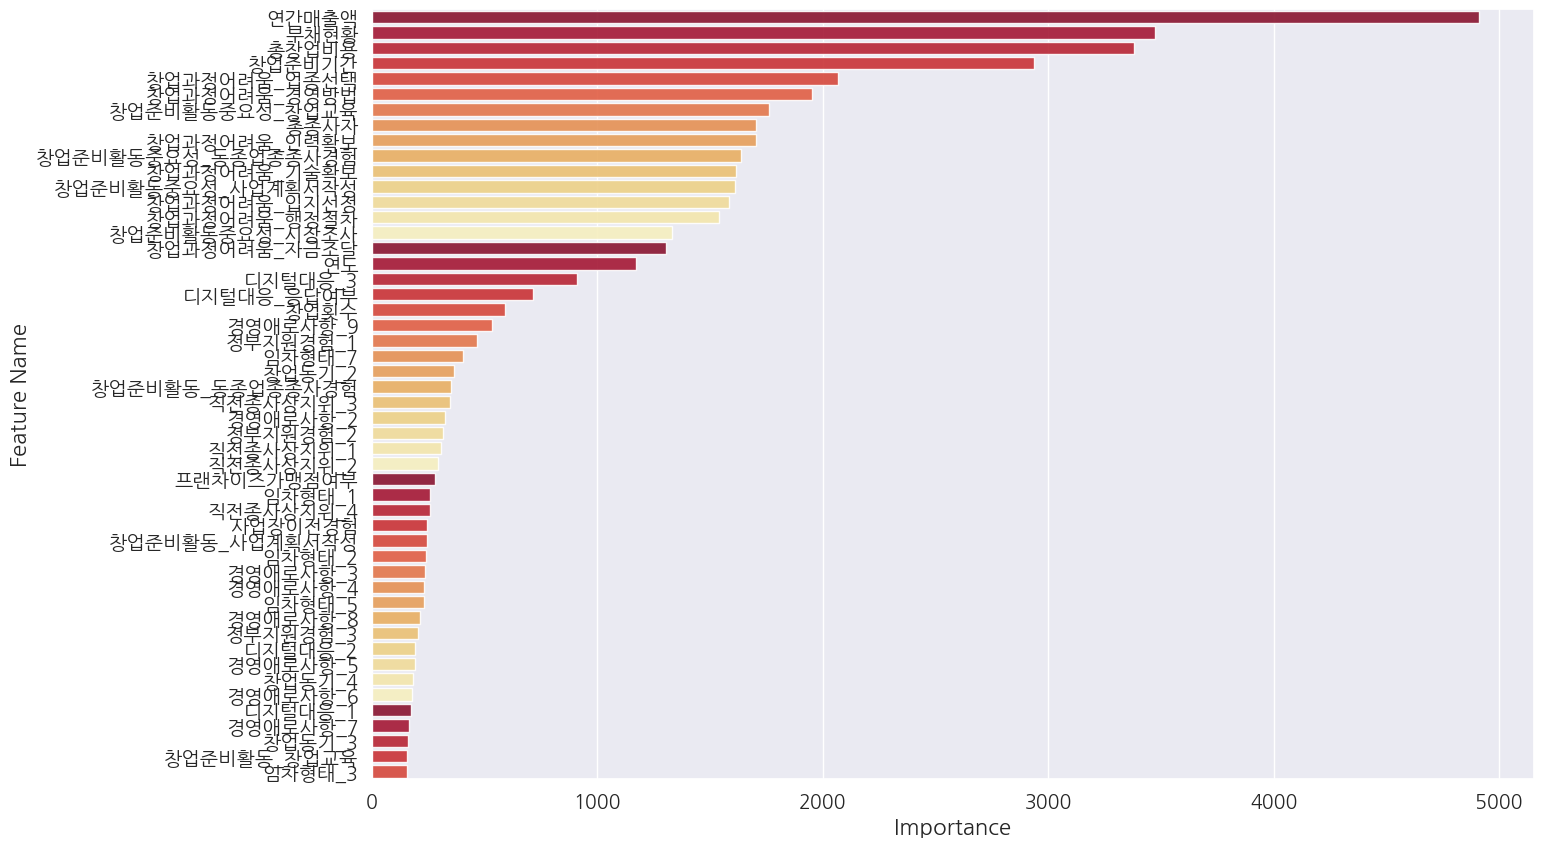

Performance Evaluations...:  2026-05-28 14:09:08.177328
Performance: 


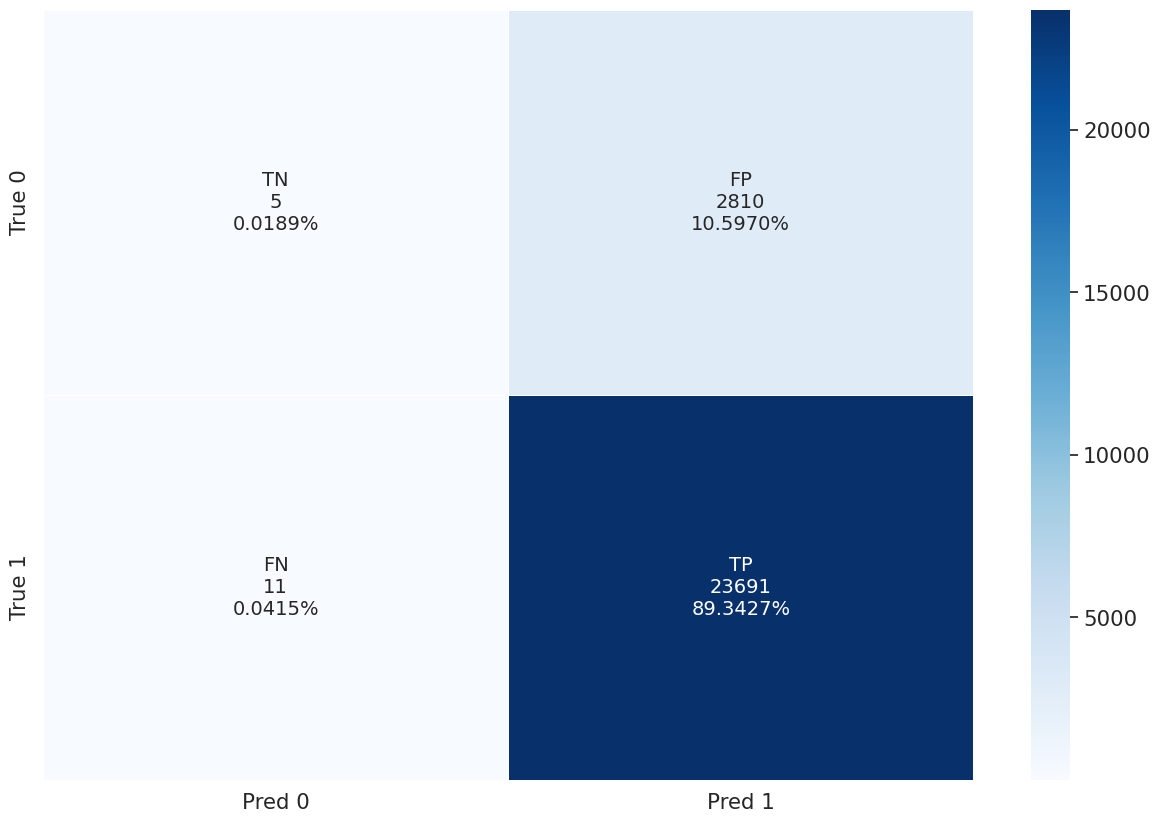

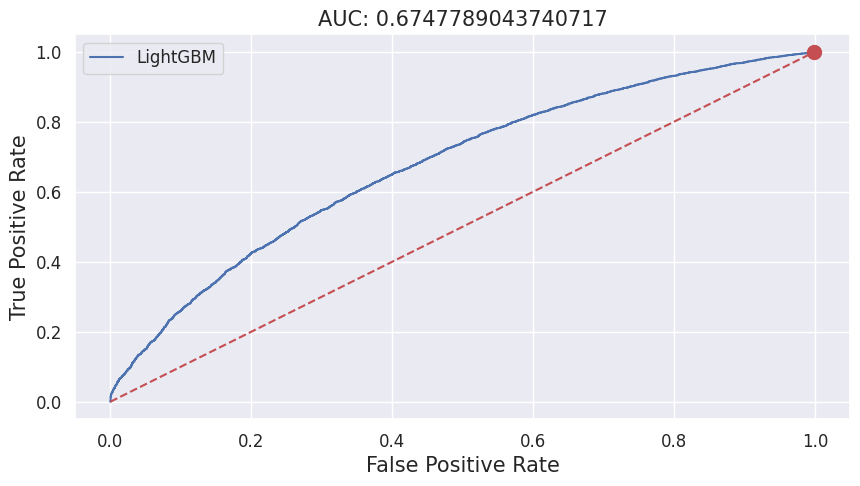

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,LightGBM,Train set,112151,55293,50416,6432,10,0.8958,0.9998,0.8869,0.9450,0.9426,0.9433,0.9796
1,LightGBM,Validation(CV),112151,55219,50272,6576,84,0.8944,0.9991,0.8853,0.9439,0.9414,0.9422,0.9637
2,LightGBM,Test set,26517,23691,5,2810,11,0.8940,0.9995,0.0018,0.9438,0.8936,0.5007,0.6748
3,LightGBM,Entire population,138668,78984,50421,9242,21,0.8952,0.9997,0.8451,0.9446,0.9332,0.9224,0.9653


   [Save] LightGBM Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_model_LightGBM_20260528_164855.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_params_LightGBM_20260528_164855.json

   Running Machine Learning Algorithm: CatBoost (classification)
Learning...:  2026-05-28 16:48:55.945346


  0%|          | 0/10 [00:00<?, ?it/s]

[CatBoost] Best Optuna Score (F1-score):  0.9436425772283752
[CatBoost] Best Tuning Parameters:  {'iterations': 750, 'depth': 7, 'learning_rate': 0.038672539386949055, 'l2_leaf_reg': 3.054930767723249, 'subsample': 0.9508934481151511, 'grow_policy': 'Lossguide', 'random_state': 123, 'verbose': 0, 'allow_writing_files': False}

Explanations...:  2026-05-28 16:52:32.593876
Explanations of Y:


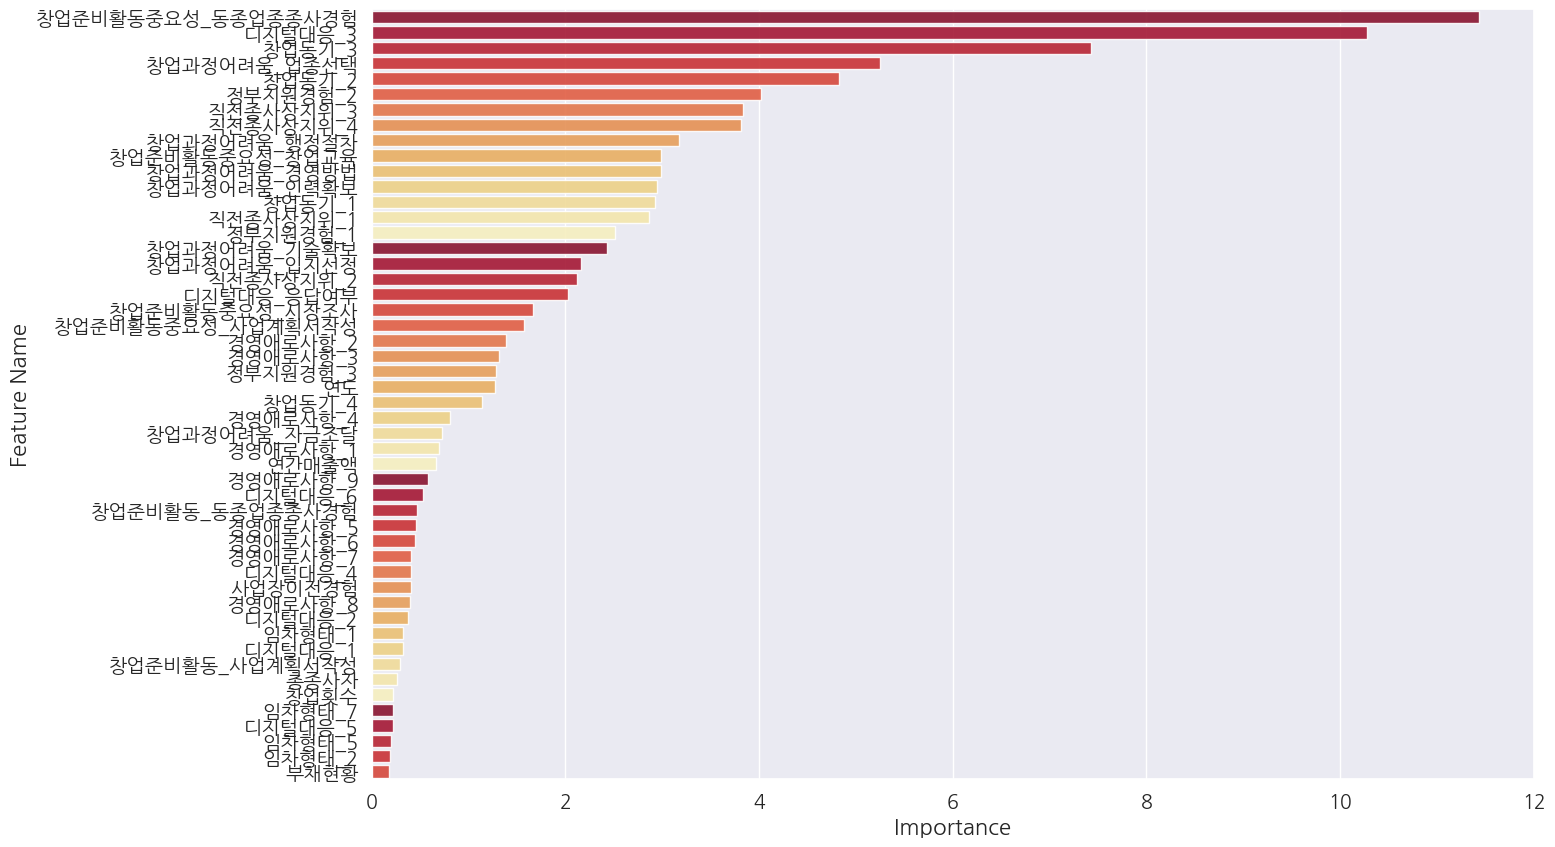

Performance Evaluations...:  2026-05-28 16:52:33.084986
Performance: 


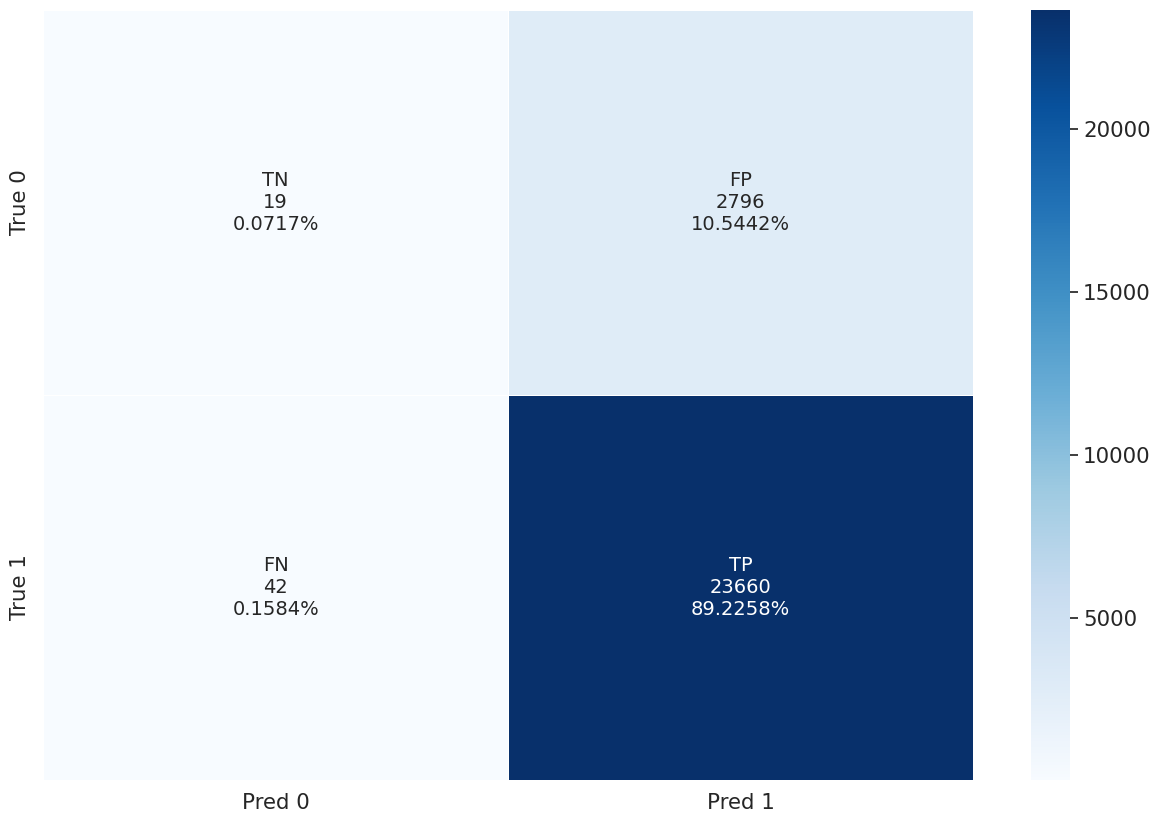

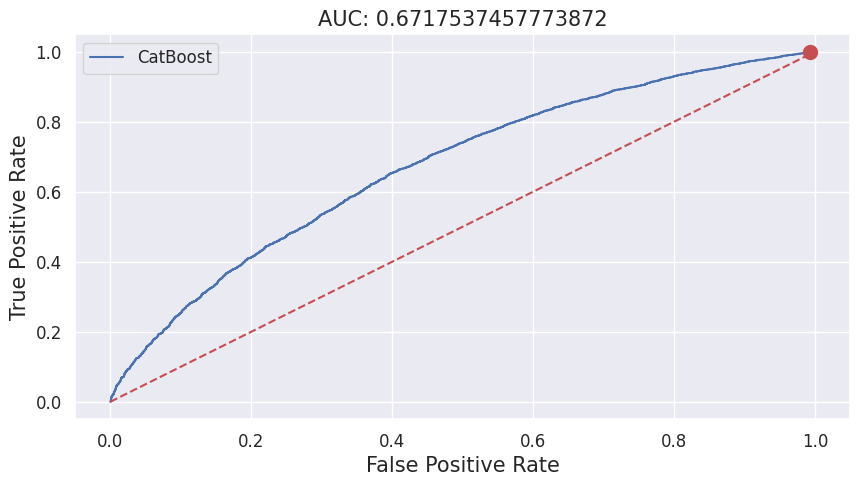

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,CatBoost,Train set,112151,55288,50730,6118,15,0.9004,0.9997,0.8924,0.9475,0.9453,0.9461,0.9797
1,CatBoost,Validation(CV),112151,55104,50260,6588,199,0.8946,0.9983,0.8856,0.9436,0.9412,0.9420,0.9624
2,CatBoost,Test set,26517,23660,19,2796,42,0.8943,0.9982,0.0067,0.9434,0.8930,0.5025,0.6718
3,CatBoost,Entire population,138668,78948,50749,8914,57,0.8985,0.9993,0.8506,0.9462,0.9353,0.9249,0.9653


   [Save] CatBoost Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_model_CatBoost_20260528_165312.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/best_params_CatBoost_20260528_165312.json

   Modeling Completed. Summary of Performance (classification)


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,Train set,112151,55118,49561,7287,185,0.883231,0.996655,0.871816,0.936521,0.933376,0.934235,0.954024
4,Random Forest,Train set,112151,55303,52914,3934,0,0.933589,1.000000,0.930798,0.965654,0.964922,0.965399,0.999979
8,XGBoost,Train set,112151,55303,50285,6563,0,0.893916,1.000000,0.884552,0.943987,0.941481,0.942276,0.977113
12,LightGBM,Train set,112151,55293,50416,6432,10,0.895796,0.999819,0.886856,0.944953,0.942560,0.943338,0.979577
16,CatBoost,Train set,112151,55288,50730,6118,15,0.900368,0.999729,0.892380,0.947450,0.945315,0.946054,0.979725


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
1,Logistic Regression,Validation(CV),112151,55149,49544,7304,154,0.883217,0.996709,0.871781,0.936535,0.933384,0.934245,0.953404
5,Random Forest,Validation(CV),112151,55144,50066,6782,159,0.894112,0.998047,0.885009,0.943224,0.940750,0.941528,0.964214
9,XGBoost,Validation(CV),112151,55296,50227,6621,7,0.893210,0.999928,0.883690,0.943559,0.941008,0.941809,0.962788
13,LightGBM,Validation(CV),112151,55219,50272,6576,84,0.894437,0.999132,0.885273,0.943888,0.941418,0.942202,0.963698
17,CatBoost,Validation(CV),112151,55104,50260,6588,199,0.894649,0.998318,0.885625,0.943643,0.941195,0.941972,0.962401


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
2,Logistic Regression,Test set,26517,23619,4,2811,83,0.893644,0.996498,0.001421,0.942272,0.890862,0.498960,0.620644
6,Random Forest,Test set,26517,23655,19,2796,47,0.894295,0.998017,0.006750,0.943313,0.892786,0.502383,0.650934
10,XGBoost,Test set,26517,23702,0,2815,0,0.893842,1.000000,0.000000,0.943946,0.893842,0.500000,0.668102
14,LightGBM,Test set,26517,23691,5,2810,11,0.893966,0.999536,0.001776,0.943808,0.893615,0.500656,0.674779
18,CatBoost,Test set,26517,23660,19,2796,42,0.894315,0.998228,0.006750,0.943419,0.892974,0.502489,0.671754


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
3,Logistic Regression,Entire population,138668,78737,49565,10098,268,0.886329,0.996608,0.830749,0.938239,0.925246,0.913679,0.938289
7,Random Forest,Entire population,138668,78958,52933,6730,47,0.921459,0.999405,0.887200,0.958851,0.951128,0.943302,0.988789
11,XGBoost,Entire population,138668,79005,50285,9378,0,0.893894,1.000000,0.842817,0.943974,0.932371,0.921409,0.962589
15,LightGBM,Entire population,138668,78984,50421,9242,21,0.895246,0.999734,0.845097,0.944610,0.933200,0.922415,0.965270
19,CatBoost,Entire population,138668,78948,50749,8914,57,0.898545,0.999279,0.850594,0.946239,0.935306,0.924936,0.965303


test
Saved total performance to: /mnt/c/DataScience/[DIVE]/Brand/KTY/Result/Performance_ML(Trial10).csv
Saved total parameters to: /mnt/c/DataScience/[DIVE]/Brand/KTY/Result/Hyperparams_ML(Trial10).csv
Saved total results object to: /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/Best_Result_ML(Trial10).pkl


In [5]:
# Setting
algorithm_list = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
# algorithm_list = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

# ML 실행
results_ML, scores_ML = modeling_ML(
    algos=algorithm_list,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    X_colname=X_colname,
    params=None, # 특정 알고리즘
    tune_trials=TUNE_TRIALS_ML, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC,
    shap=not SHAP, 
    X_selected=None, # shap에서만 작동
    interaction=not INTERACTION,
    interaction_samples=INTERACTION_SAMPLES, 
    X_top_display=X_TOP_DISPLAY, 
    label_list=LABEL_LIST,
)

## Deep Learning

In [ ]:
# # Setting
# algorithm_list = ['MLP', 'CNN']
# # algorithm_list = ['CNN']

# # DL 실행
# results_DL, scores_DL = modeling_DL(
#     algos=algorithm_list,
#     X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
#     node_list=None, # 특정 알고리즘
#     validation_split=VALIDATION_SPLIT,
#     validation_data=VALIDATION_DATA,
#     tune_trials=TUNE_TRIALS_DL, # 최적화 여부
#     cv_splits=CV_SPLITS,
#     tune_metric=TUNE_METRIC_DL,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     earlystop_patient=None,
#     shap_display=False,
#     label_list=LABEL_LIST,
#     random_state=RANDOM_STATE,
# )

# Performance Summary

In [5]:
# Algorithms Loaded
# algo_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP', 'CNN']
algo_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

# Result Summary
folder_location = os.path.join(os.getcwd(),'Result')
scores = prediction_summary(
    folder_location=folder_location, 
    algonames=algo_names,
    save_name=SAVE_NAME_PERFORMANCE,
)

### Performance Summary : 5 Algorithms ###

>>> [Train set] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,112151,55118,49561,7287,185,0.8832,0.9967,0.8718,0.9365,0.9334,0.9342,0.9540
1,Random Forest,112151,55303,52914,3934,0,0.9336,1.0000,0.9308,0.9657,0.9649,0.9654,1.0000
2,XGBoost,112151,55303,50285,6563,0,0.8939,1.0000,0.8846,0.9440,0.9415,0.9423,0.9771
3,LightGBM,112151,55293,50416,6432,10,0.8958,0.9998,0.8869,0.9450,0.9426,0.9433,0.9796
4,CatBoost,112151,55288,50730,6118,15,0.9004,0.9997,0.8924,0.9475,0.9453,0.9461,0.9797



>>> [Validation(CV)] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,112151,55149,49544,7304,154,0.8832,0.9967,0.8718,0.9365,0.9334,0.9342,0.9534
1,Random Forest,112151,55144,50066,6782,159,0.8941,0.9980,0.8850,0.9432,0.9407,0.9415,0.9642
2,XGBoost,112151,55296,50227,6621,7,0.8932,0.9999,0.8837,0.9436,0.9410,0.9418,0.9628
3,LightGBM,112151,55219,50272,6576,84,0.8944,0.9991,0.8853,0.9439,0.9414,0.9422,0.9637
4,CatBoost,112151,55104,50260,6588,199,0.8946,0.9983,0.8856,0.9436,0.9412,0.9420,0.9624



>>> [Test set] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,26517,23619,4,2811,83,0.8936,0.9965,0.0014,0.9423,0.8909,0.4990,0.6206
1,Random Forest,26517,23655,19,2796,47,0.8943,0.9980,0.0067,0.9433,0.8928,0.5024,0.6509
2,XGBoost,26517,23702,0,2815,0,0.8938,1.0000,0.0000,0.9439,0.8938,0.5000,0.6681
3,LightGBM,26517,23691,5,2810,11,0.8940,0.9995,0.0018,0.9438,0.8936,0.5007,0.6748
4,CatBoost,26517,23660,19,2796,42,0.8943,0.9982,0.0067,0.9434,0.8930,0.5025,0.6718



>>> [Entire population] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,138668,78737,49565,10098,268,0.8863,0.9966,0.8307,0.9382,0.9252,0.9137,0.9383
1,Random Forest,138668,78958,52933,6730,47,0.9215,0.9994,0.8872,0.9589,0.9511,0.9433,0.9888
2,XGBoost,138668,79005,50285,9378,0,0.8939,1.0000,0.8428,0.9440,0.9324,0.9214,0.9626
3,LightGBM,138668,78984,50421,9242,21,0.8952,0.9997,0.8451,0.9446,0.9332,0.9224,0.9653
4,CatBoost,138668,78948,50749,8914,57,0.8985,0.9993,0.8506,0.9462,0.9353,0.9249,0.9653


# Best Model Prediction

▶ Searching Directory: /mnt/c/DataScience/[DIVE]/Brand/KTY/Model
Loading Model: LightGBM
   - File: best_model_LightGBM_20260528_164855.pkl
   - Successfully Loaded.
Performance: 


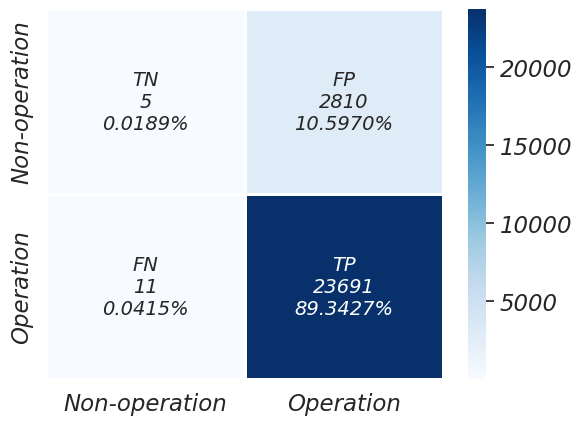

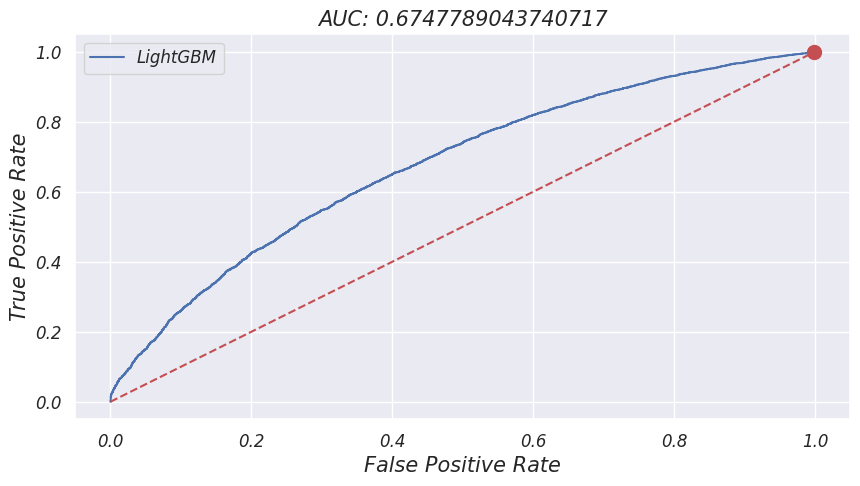

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,LightGBM,Train set,112151,55293,50416,6432,10,0.8958,0.9998,0.8869,0.9450,0.9426,0.9433,0.9796
1,LightGBM,Test set,26517,23691,5,2810,11,0.8940,0.9995,0.0018,0.9438,0.8936,0.5007,0.6748
2,LightGBM,Entire population,138668,78984,50421,9242,21,0.8952,0.9997,0.8451,0.9446,0.9332,0.9224,0.9653


In [6]:
# Model Loaded
best_scoreidx = np.argmax(scores[scores.Dataset=='Test set']['AUC'])
# best_scoreidx = np.argmax(scores[scores.Dataset=='Test set'][METRIC_FINAL])
best_algo = scores[scores.Dataset=='Test set'].iloc[best_scoreidx]['Algorithm']
# best_algo = 'XGBoost'
best_model, best_params = Loading_ModelBestParams(algo_name=best_algo)

# Performance Evaluation
Scores_Test = prediction_class(best_model, X_train, Y_train, X_test, Y_test,
                             LABEL_LIST=LABEL_LIST, ALGO_NAME=best_algo, keras=False)
display(Scores_Test)

# Explanation

▶ Detected Task Type: [ classification ] (Target: binary)

   Running Machine Learning Algorithm: LightGBM (classification)
Explanations...:  2026-05-28 21:39:10.907873
Total SHAP Calculation...: 2026-05-28 21:39:10.910948


100%|===================| 26498/26517 [15:15<00:00]          

SHAP values saved to /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/shap_values_LightGBM_20260528_225427.pkl
Train Dataset: 2026-05-28 22:54:28.407522
Total Explanation (Beeswarm + Importance Bar)...


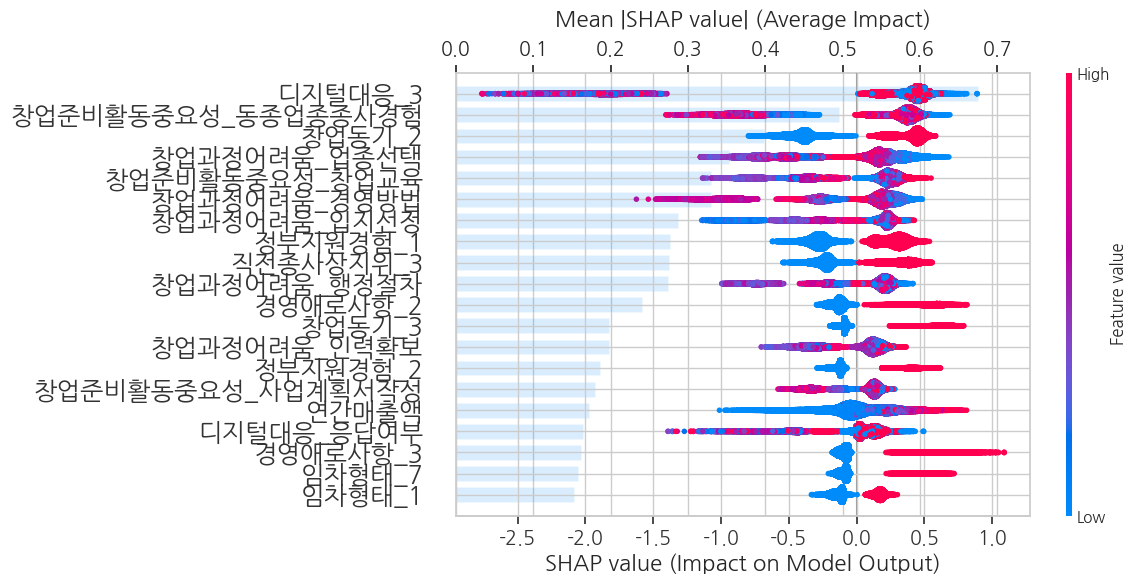

Test Dataset: 2026-05-28 22:54:43.725362
Total Explanation (Beeswarm + Importance Bar)...


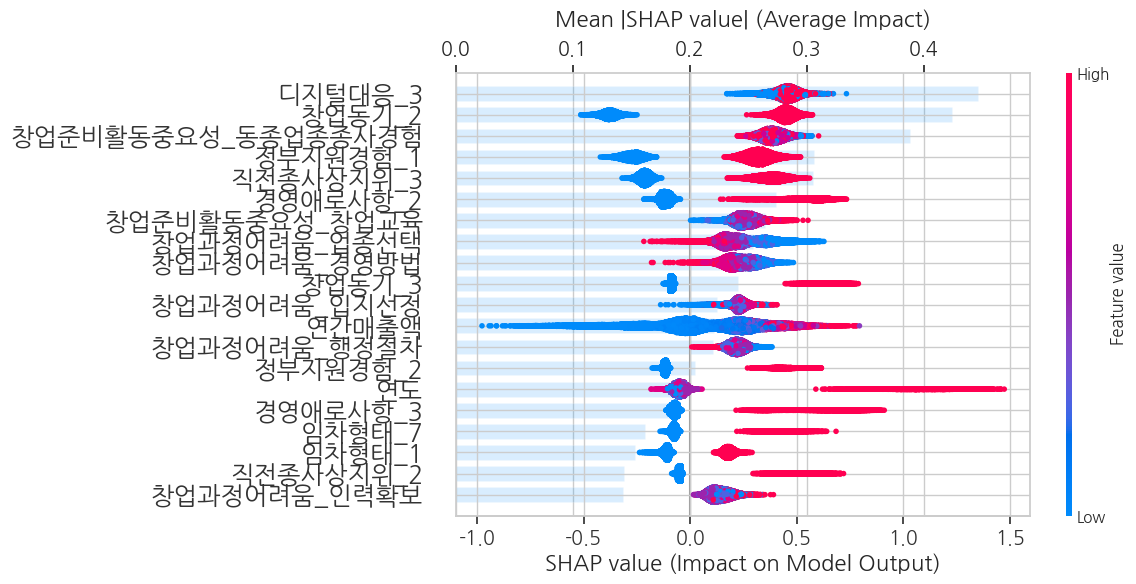

Test Dataset: 2026-05-28 22:54:47.513048
Feature Total Contribution...
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 107.99it/s]


,Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression),Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression)
0,디지털대응_3,0.4467,0.4467,0.4436,0.1072,0.0544,+,+,+,창업준비활동중요성_동종업종종사경험,0.3886,0.3886,-0.2279,-0.0428,0.0000,-,-,+
1,창업동기_2,0.4245,0.8271,0.9957,0.8271,0.8271,+,+,+,창업과정어려움_업종선택,0.2540,0.3035,-0.8628,-0.3228,0.0000,-,-,+
2,정부지원경험_1,0.3059,0.5924,0.9828,0.5924,0.5924,+,+,+,창업과정어려움_경영방법,0.2417,0.2820,-0.7788,-0.1958,0.0000,-,-,+
3,직전종사상지위_3,0.3053,0.5922,0.9875,0.5922,0.5922,+,+,+,창업과정어려움_행정절차,0.2199,0.2199,-0.1471,-0.0208,-0.2440,-,-,-
4,경영애로사항_2,0.2737,0.6403,0.9770,0.6403,0.6403,+,+,+,창업준비활동중요성_사업계획서작성,0.1418,0.1418,-0.2300,-0.0230,0.0000,-,-,+


,Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression),Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression)
0,창업동기_1,0.0571,0.7421,0.9985,0.7421,0.7421,+,+,+,디지털대응_1,0.0118,0.0285,-0.9164,-0.1066,-0.0554,-,-,-
1,창업동기_3,0.2413,0.7313,0.9966,0.7313,0.7313,+,+,+,창업과정어려움_업종선택,0.2540,0.3035,-0.8628,-0.3228,0.0000,-,-,+
2,창업동기_2,0.4245,0.8271,0.9957,0.8271,0.8271,+,+,+,디지털대응_2,0.0127,0.0963,-0.7825,-0.0750,-0.0326,-,-,-
3,창업동기_4,0.0174,0.9754,0.9944,0.9754,0.9754,+,+,+,창업과정어려움_경영방법,0.2417,0.2820,-0.7788,-0.1958,0.0000,-,-,+
4,임차형태_2,0.0526,0.4265,0.9941,0.4265,0.4265,+,+,+,프랜차이즈가맹점여부,0.0136,0.1344,-0.7483,-0.1375,-0.1375,-,-,-


Interaction SHAP Calculation...: 2026-05-28 22:54:48.113654
SHAP intervalues saved to /mnt/c/DataScience/[DIVE]/Brand/KTY/Model/shap_intervalues_LightGBM_20260528_231052.pkl
Test Dataset Interaction: 2026-05-28 23:10:53.098505
Feature Interactive Contribution...


Calculating Interactions: 100%|████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 537.33it/s]


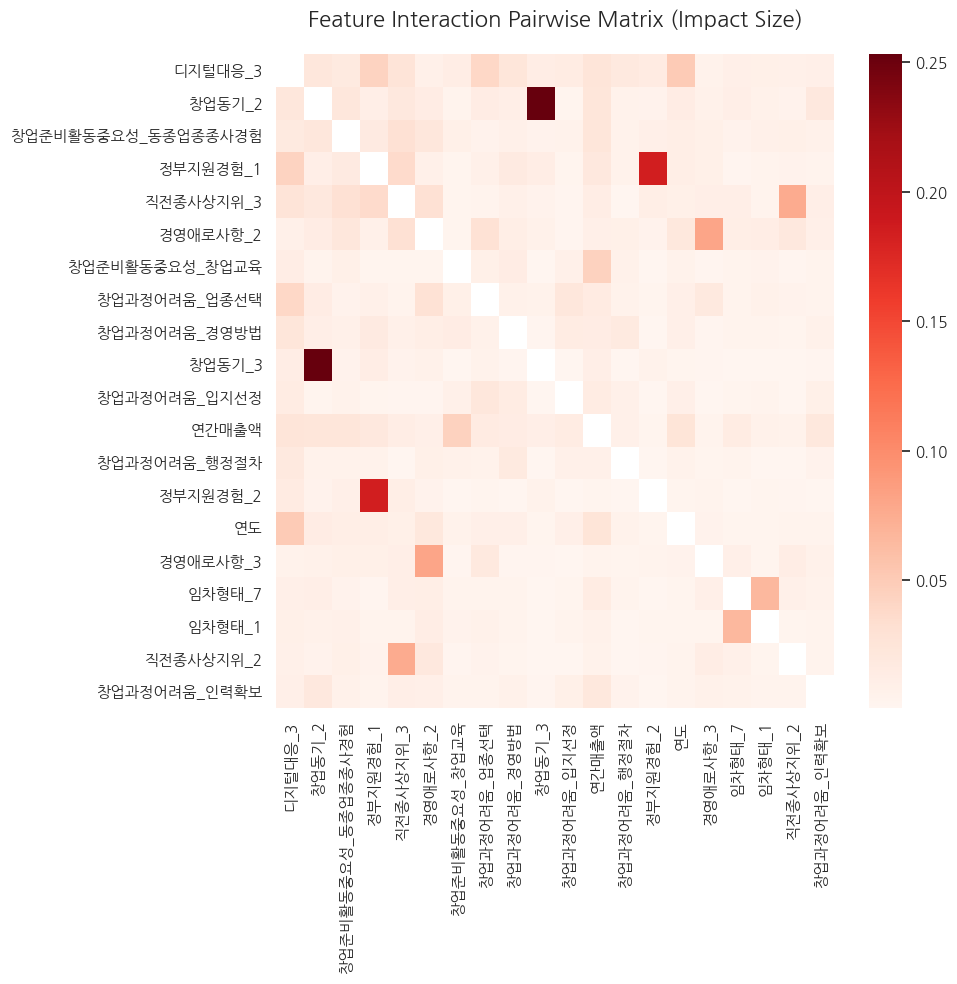

Calculating Correlations: 100%|████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 526.56it/s]


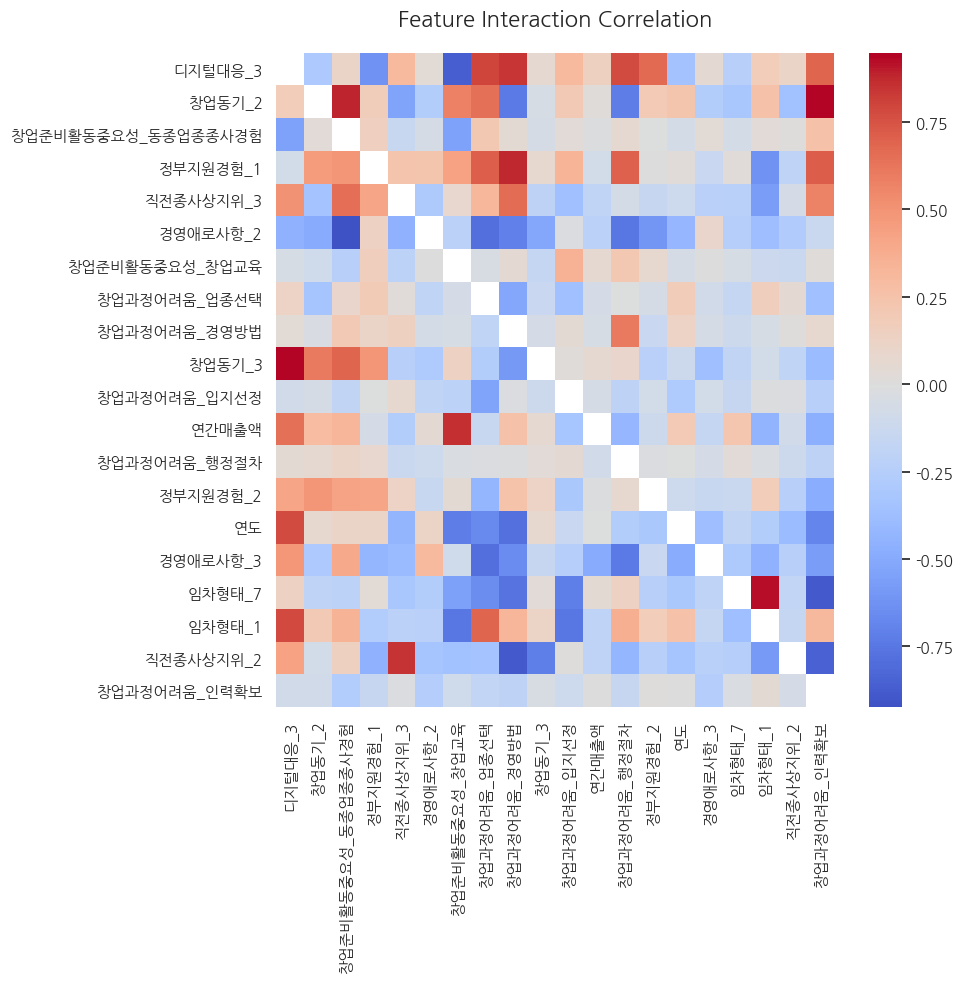


Test Dataset Sensitivity Analysis: 2026-05-28 23:10:54.133472
Sensitivity Analysis (ICE & PDP Plot) for Top 20 Features...


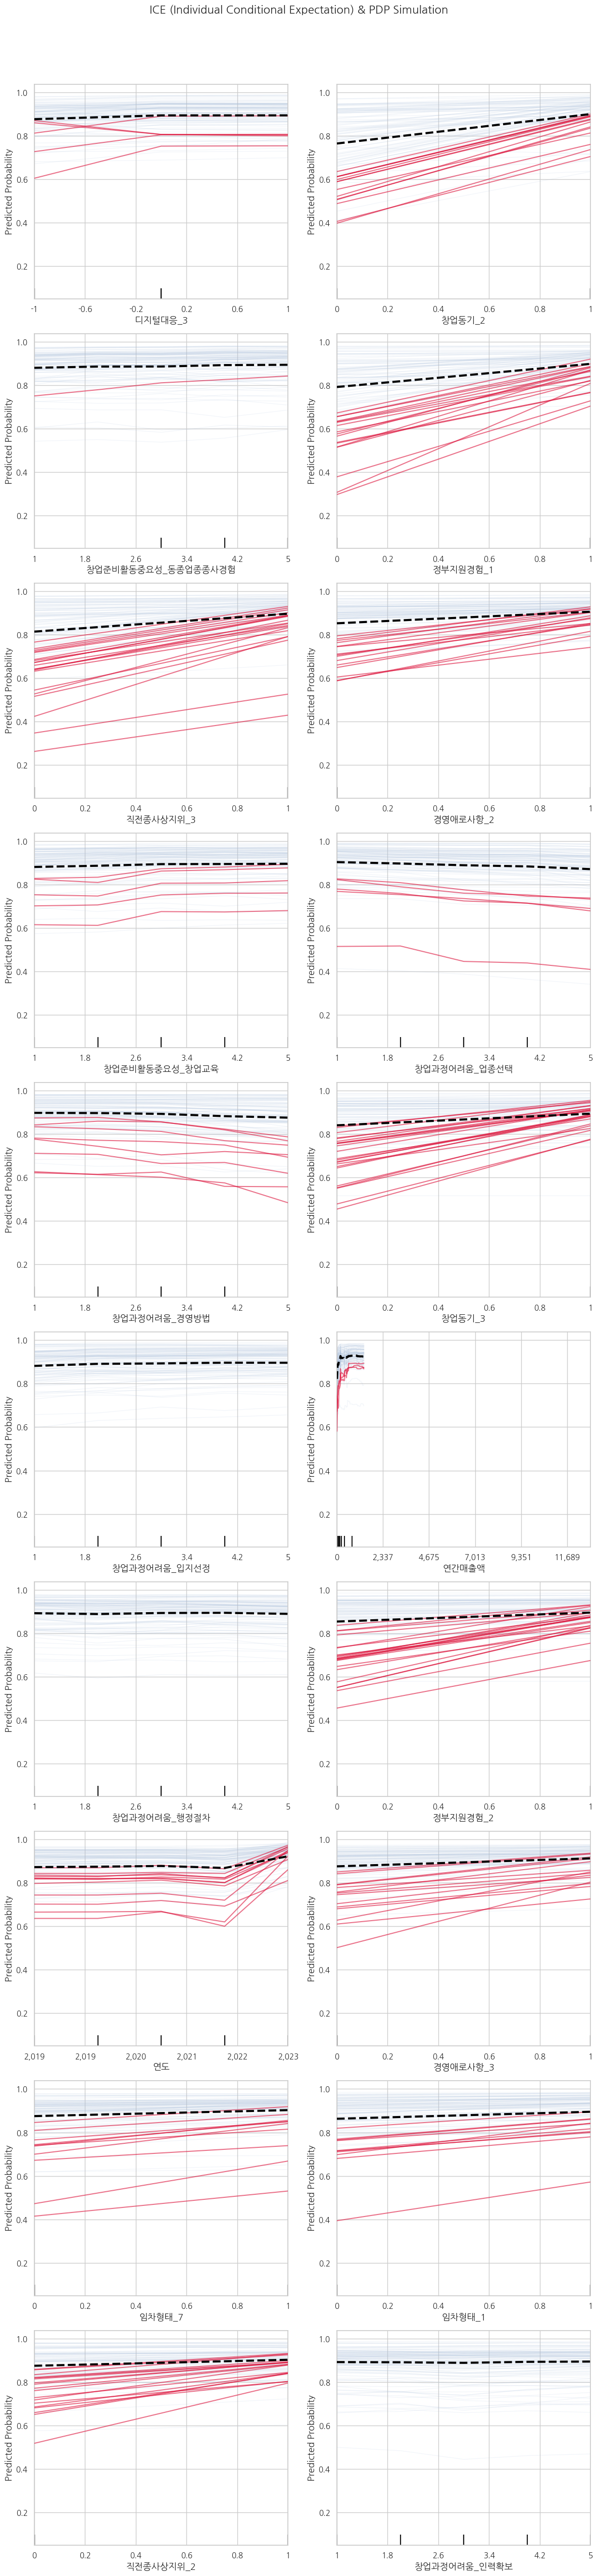

Train Dataset: 2026-05-28 23:11:06.858654
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 9045


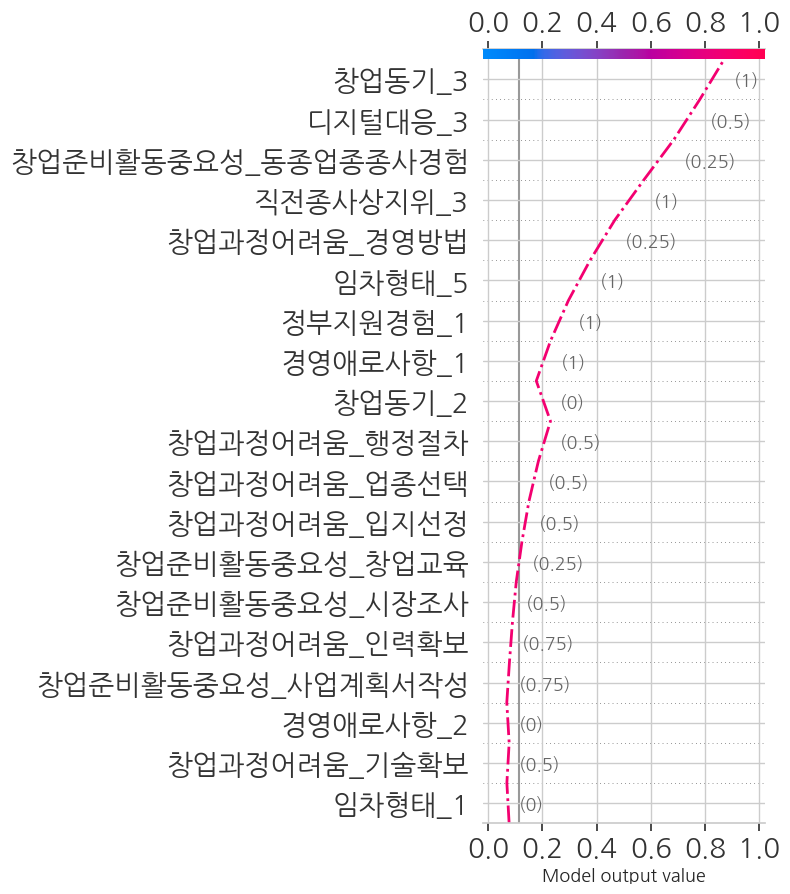

Test Dataset: 2026-05-28 23:11:07.069886
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 5879


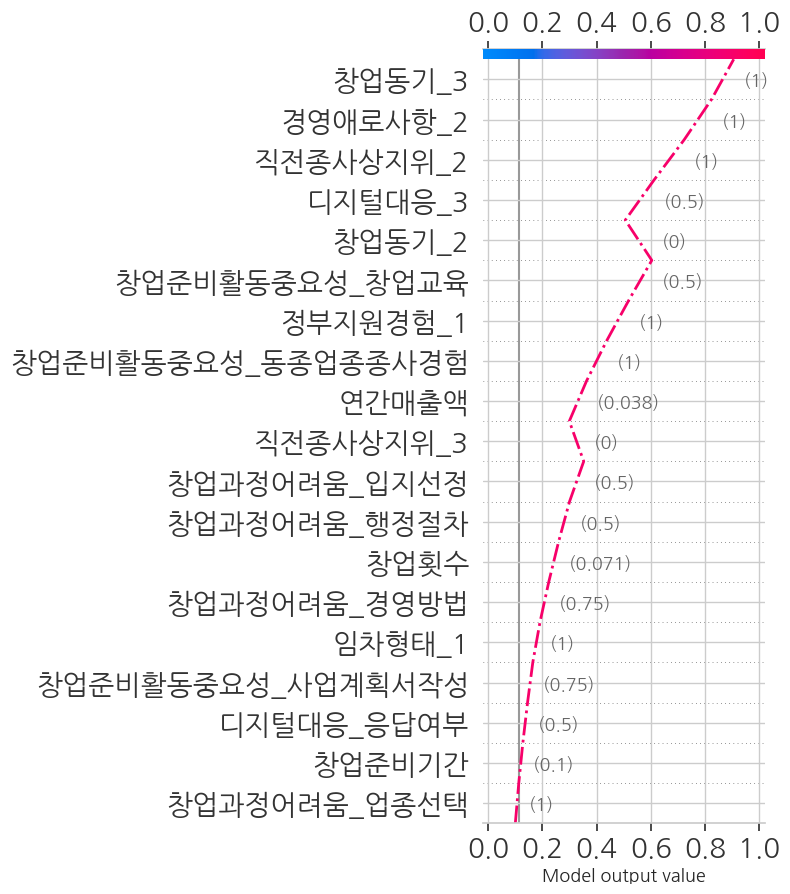

Performance Evaluations...:  2026-05-28 23:11:07.272846
Performance: 


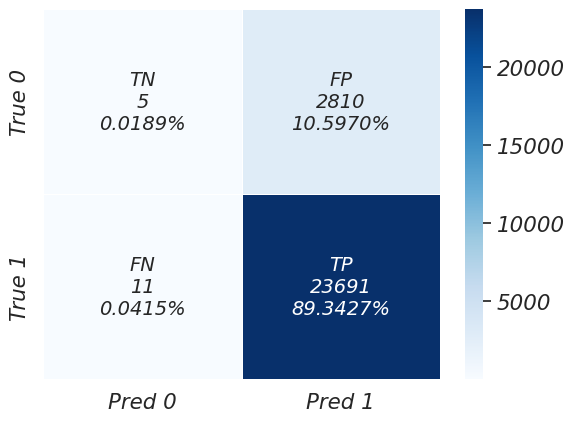

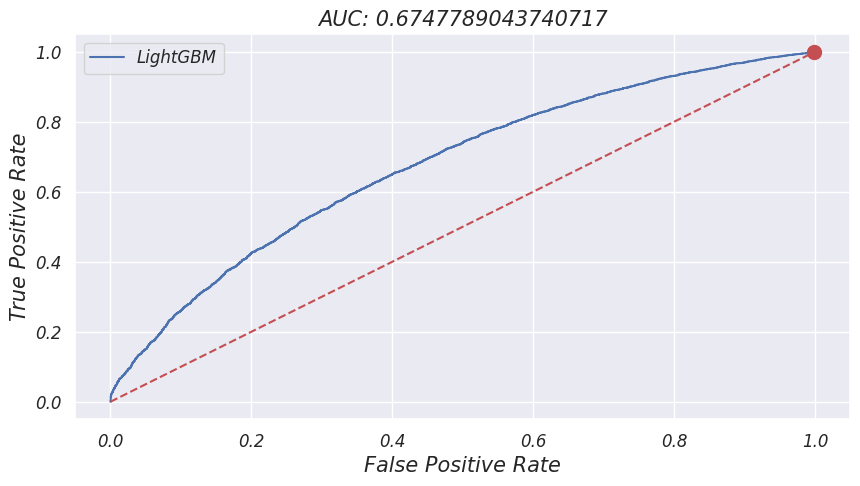

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,LightGBM,Train set,112151,55293,50416,6432,10,0.8958,0.9998,0.8869,0.9450,0.9426,0.9433,0.9796
1,LightGBM,Test set,26517,23691,5,2810,11,0.8940,0.9995,0.0018,0.9438,0.8936,0.5007,0.6748
2,LightGBM,Entire population,138668,78984,50421,9242,21,0.8952,0.9997,0.8451,0.9446,0.9332,0.9224,0.9653



   Modeling Completed. Summary of Performance (classification)


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,LightGBM,Train set,112151,55293,50416,6432,10,0.895796,0.999819,0.886856,0.944953,0.942560,0.943338,0.979577


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
1,LightGBM,Test set,26517,23691,5,2810,11,0.893966,0.999536,0.001776,0.943808,0.893615,0.500656,0.674779


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
2,LightGBM,Entire population,138668,78984,50421,9242,21,0.895246,0.999734,0.845097,0.944610,0.933200,0.922415,0.965270


In [7]:
# Setting
algorithm_list = [best_algo]
params = best_params
TUNE_TRIALS = None
# df_domain_rename = pd.read_excel(os.path.join(FOLDER_GDM, '[Rename_20251228].xlsx'), sheet_name='Features_SI')
# df_domain_rename = {i[0]:i[1] for i in df_domain_rename[['변수설명(한글)', '변수설명(영어)']].values}
# if LANGUAGE == 'kr':
#     X_selected = [col for col in X_colname if col in list(df_domain_rename.keys())]
# else:
#     X_selected = [df_rename[col] for col in X_colname if col in list(df_domain_rename.keys())]

# ML 실행
results_SHAP, scores_SHAP = modeling_ML(
    algos=algorithm_list,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    X_colname=X_colname, 
    scaler_dict=scaler,
    params=params, # 특정 알고리즘
    tune_trials=TUNE_TRIALS, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC,
    shap=SHAP, 
    X_selected=None, # shap에서만 작동
    interaction=INTERACTION,
    interaction_samples=INTERACTION_SAMPLES, 
    X_top_display=X_TOP_DISPLAY-30, 
    label_list=LABEL_LIST,
)

# Group Analysis


★★★ Subgroup Performance (Fairness) Evaluation: [연도] ★★★
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (2019Y)
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (2020Y)
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (2021Y)
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (2022Y)
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (2023Y)


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,AUC
0,연도,2019Y,4364,0.8673,0.9997,0.0000,0.9288,0.8671,0.6522
1,연도,2020Y,4180,0.8643,0.9986,0.0070,0.9266,0.8634,0.6477
2,연도,2021Y,7125,0.9024,0.9997,0.0000,0.9486,0.9022,0.6325
3,연도,2022Y,6987,0.8864,0.9995,0.0013,0.9396,0.8861,0.6635
4,연도,2023Y,3861,0.9542,1.0000,0.0000,0.9765,0.9542,0.7010



★★★ Subgroup Analysis Pipeline: 기준 변수 [연도] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_LightGBM_20260528_225427.pkl



################################################################################
🚀 실행 중인 데이터셋: [ Train Set ]
################################################################################

------------------------------------------------------------
### [Train Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction...


100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [00:01<00:00, 44.67it/s]



------------------------------------------------------------
### [연도] - 2019Y Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 21001명

[2019Y] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


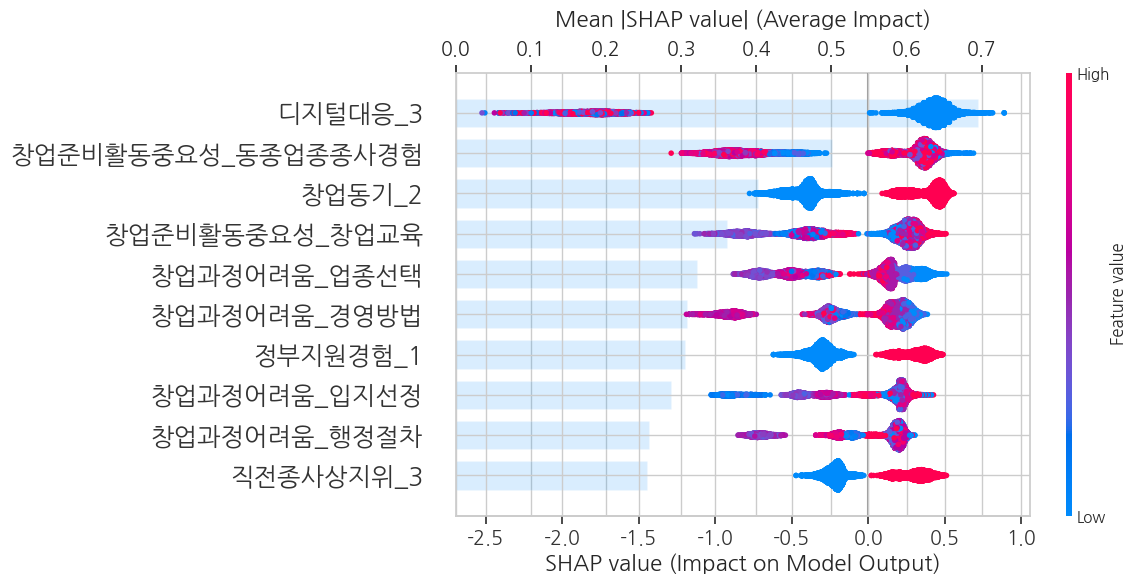

Feature Total Contribution...
Feature Contribution Direction...


100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 88.76it/s]


Feature Contribution Direction...


100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 85.96it/s]



------------------------------------------------------------
### [연도] - 2020Y Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 24449명

[2020Y] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


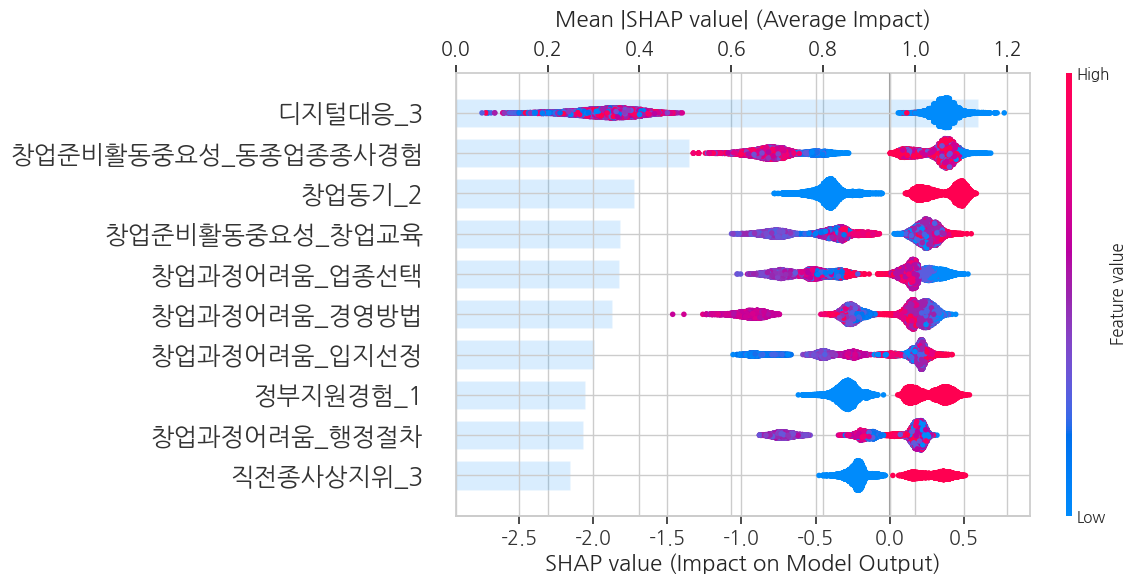

Feature Total Contribution...
Feature Contribution Direction...


100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 90.48it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 103.46it/s]



------------------------------------------------------------
### [연도] - 2021Y Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 33201명

[2021Y] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


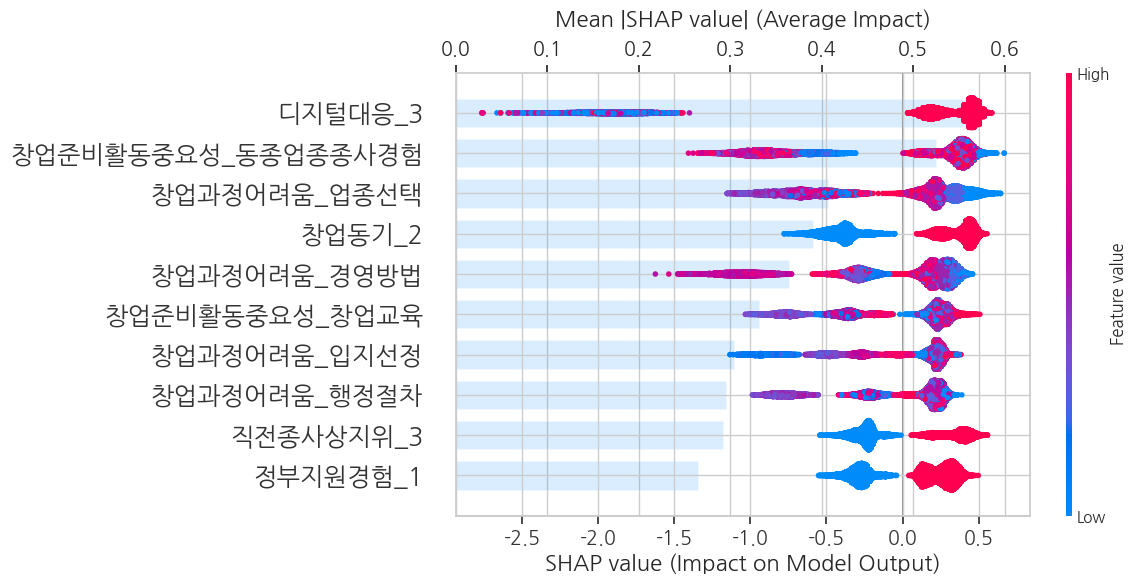

Feature Total Contribution...
Feature Contribution Direction...


100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 93.91it/s]


Feature Contribution Direction...


100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 93.00it/s]



------------------------------------------------------------
### [연도] - 2022Y Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 24022명

[2022Y] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


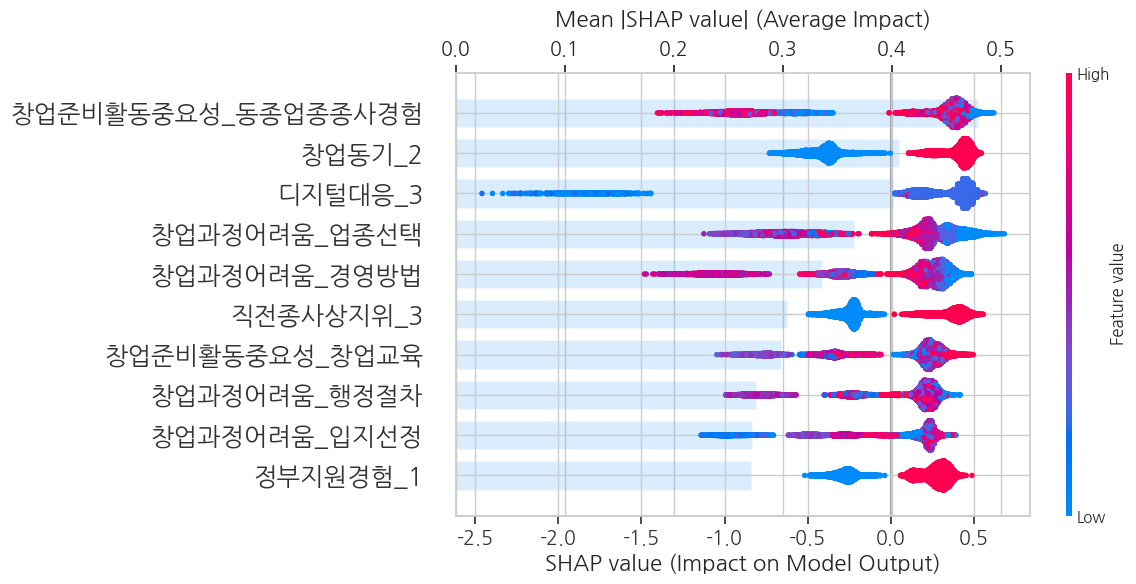

Feature Total Contribution...
Feature Contribution Direction...


100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 88.83it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 103.71it/s]



------------------------------------------------------------
### [연도] - 2023Y Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 9478명

[2023Y] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


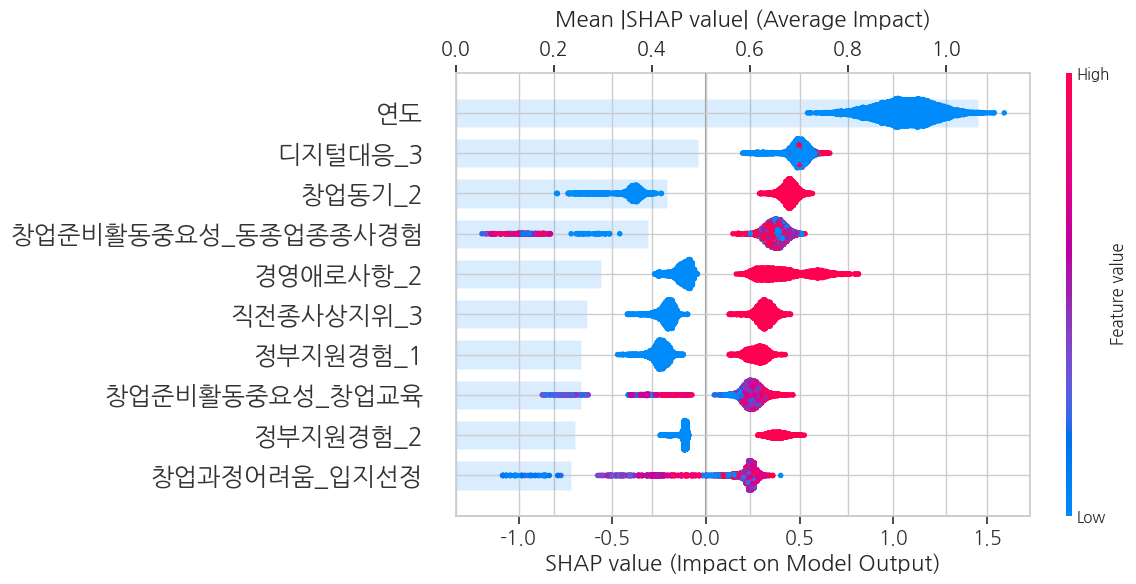

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 131.26it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 136.51it/s]


### Group Rank & Direction Master Table (Train Set, Split by: 연도) ###


,Feature,Rank_Total,DirectionQR_Total,DirectionCORR_Total,Rank_2019Y,DirectionQR_2019Y,DirectionCORR_2019Y,Rank_2020Y,DirectionQR_2020Y,DirectionCORR_2020Y,Rank_2021Y,DirectionQR_2021Y,DirectionCORR_2021Y,Rank_2022Y,DirectionQR_2022Y,DirectionCORR_2022Y,Rank_2023Y,DirectionQR_2023Y,DirectionCORR_2023Y
0,디지털대응_3,1,+,+,1,-,-,1,+,-,1,+,+,3,+,+,2,+,+
1,창업준비활동중요성_동종업종종사경험,2,+,+,2,+,+,2,+,+,2,+,+,1,+,+,4,+,+
2,창업동기_2,3,+,+,3,+,+,3,+,+,4,+,+,2,+,+,3,+,+
3,창업과정어려움_업종선택,4,+,-,5,+,-,5,+,-,3,+,-,4,+,-,14,+,-
4,창업준비활동중요성_창업교육,5,+,+,4,+,+,4,+,+,6,+,+,7,+,+,8,+,+
5,창업과정어려움_경영방법,6,+,-,6,+,-,6,+,-,5,+,-,5,+,-,13,+,-
6,창업과정어려움_입지선정,7,+,+,8,+,+,7,+,+,7,+,+,9,+,+,10,+,+
7,정부지원경험_1,8,+,+,7,+,+,8,+,+,10,+,+,10,+,+,7,+,+
8,직전종사상지위_3,9,+,+,10,+,+,10,+,+,9,+,+,6,+,+,6,+,+
9,창업과정어려움_행정절차,10,+,+,9,+,+,9,+,+,8,+,+,8,+,-,11,+,+



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Train Set)


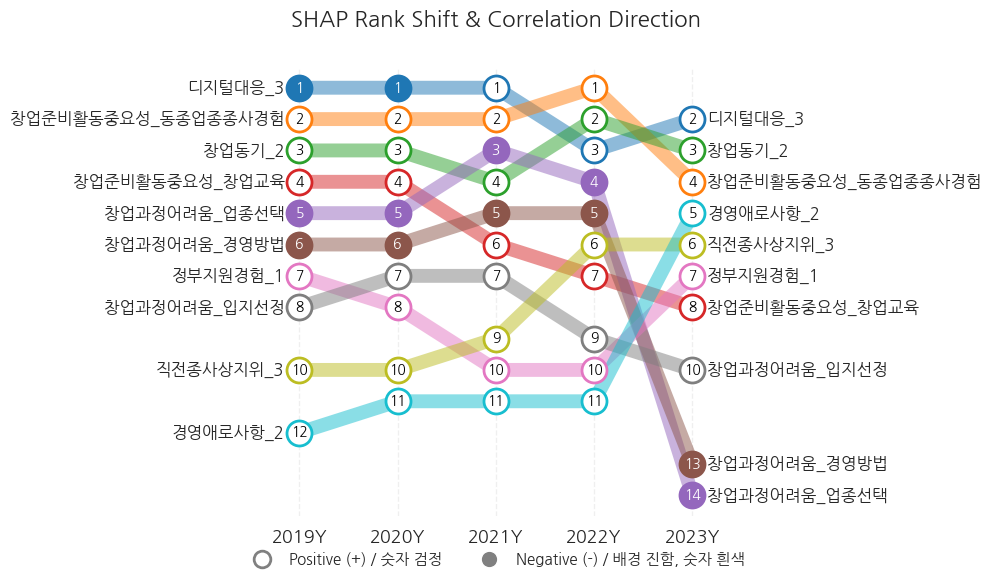


💡 [연도] 기준 하위 집단 간 방향성 이견(Discordance) 리포트 (Train Set)

▶ Correlation (CORR) 기준 엇갈리는 변수 (8개):
  - 디지털대응_3
  - 창업과정어려움_행정절차
  - 창업과정어려움_인력확보
  - 디지털대응_응답여부
  - 창업준비활동중요성_시장조사
  - 경영애로사항_9
  - 디지털대응_6
  - 디지털대응_5
▶ Quantile Regression (QR) 기준 엇갈리는 변수 (10개):
  - 디지털대응_3
  - 창업과정어려움_자금조달
  - 창업과정어려움_기술확보
  - 창업준비기간
  - 부채현황
  - 경영애로사항_9
  - 디지털대응_6
  - 디지털대응_5
  - 디지털대응_1
  - 디지털대응_2

마스터 테이블이 저장되었습니다: /mnt/c/DataScience/[DIVE]/Brand/KTY/Result/FeatureImportance_MasterTable_Train_LightGBM_연도.csv



################################################################################
🚀 실행 중인 데이터셋: [ Test Set ]
################################################################################

------------------------------------------------------------
### [Test Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 108.32it/s]



------------------------------------------------------------
### [연도] - 2019Y Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 4364명

[2019Y] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


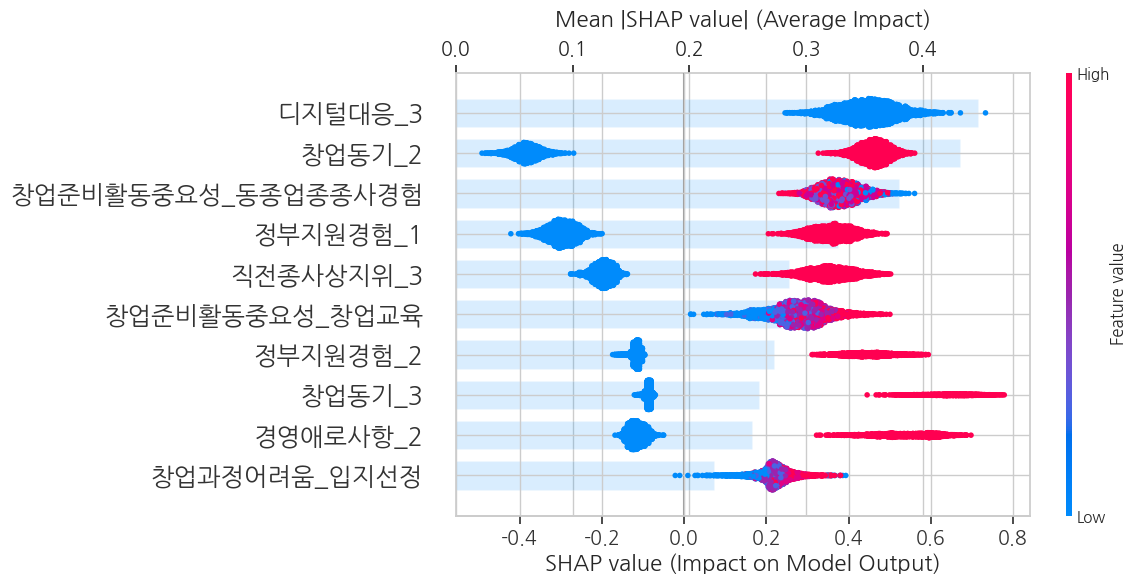

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 141.50it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 151.21it/s]



------------------------------------------------------------
### [연도] - 2020Y Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 4180명

[2020Y] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


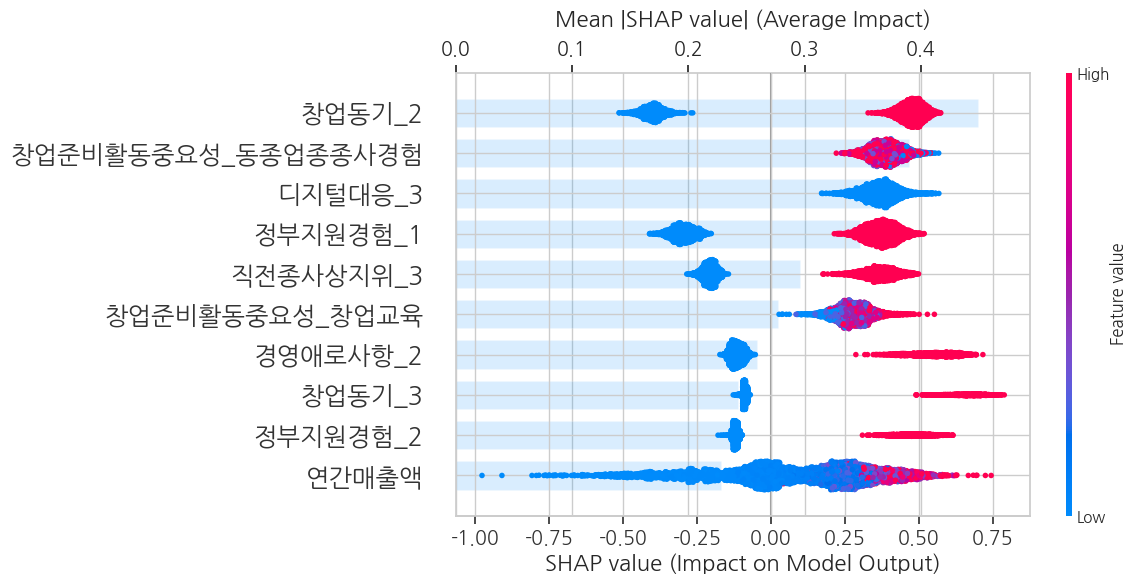

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 146.33it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 146.52it/s]



------------------------------------------------------------
### [연도] - 2021Y Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 7125명

[2021Y] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


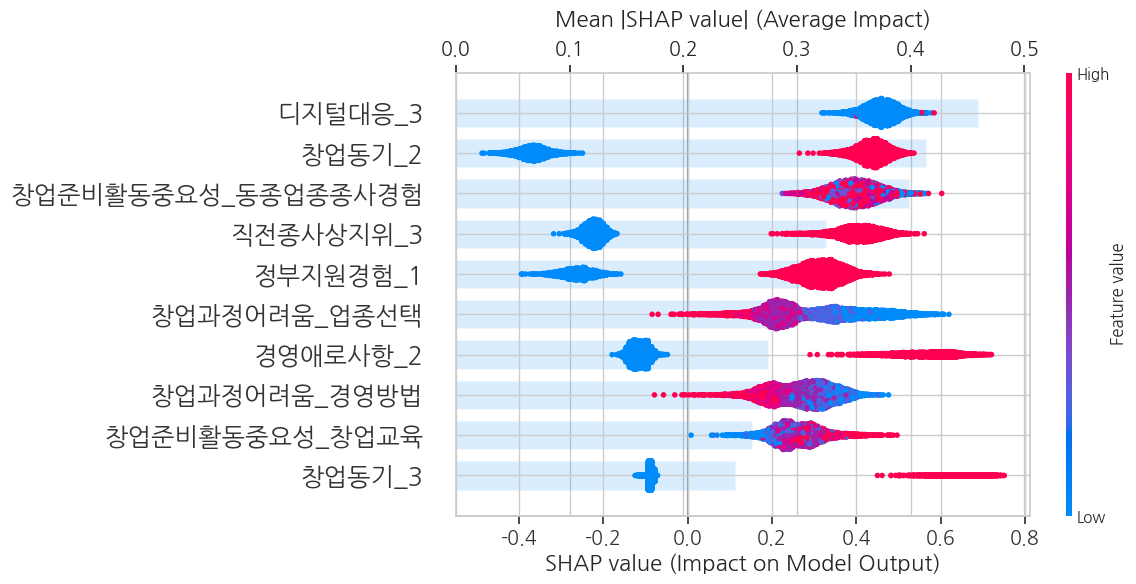

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 141.67it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 139.09it/s]



------------------------------------------------------------
### [연도] - 2022Y Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 6987명

[2022Y] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


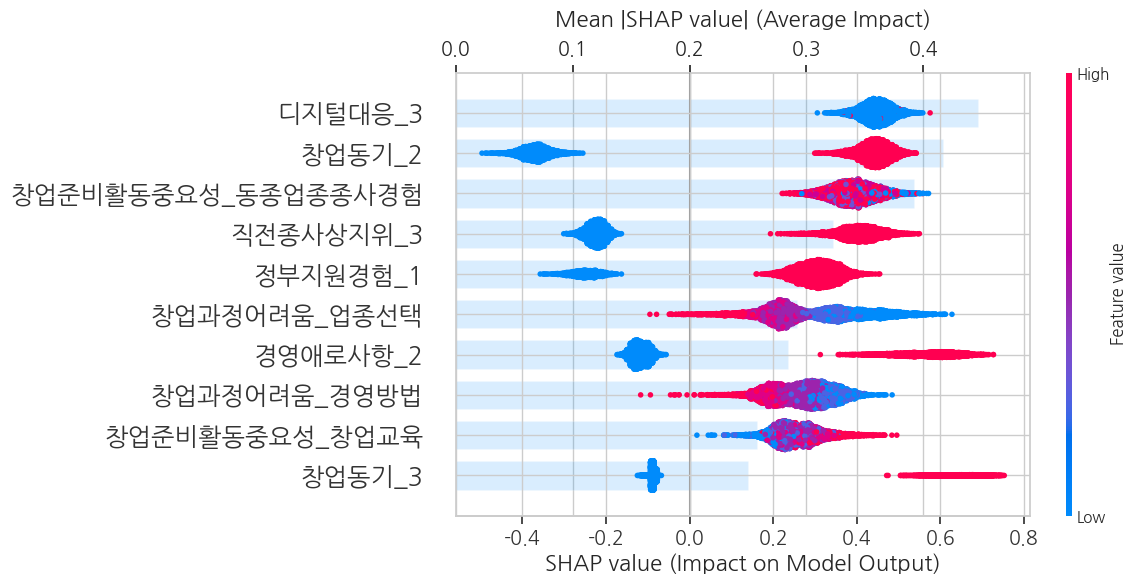

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 127.46it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 121.62it/s]



------------------------------------------------------------
### [연도] - 2023Y Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] '연도' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 3861명

[2023Y] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


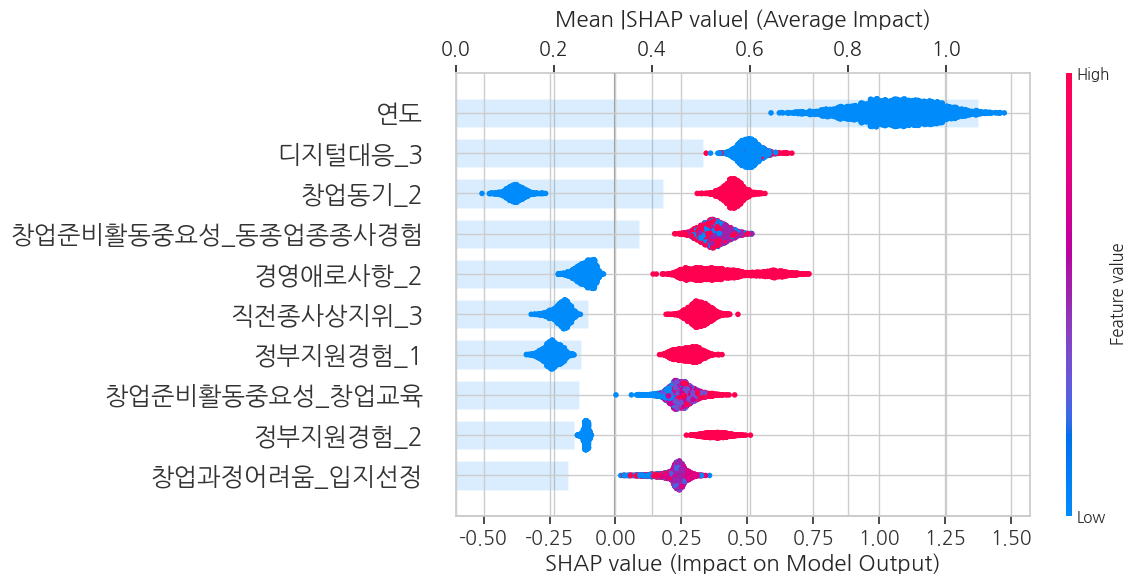

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 120.08it/s]


Feature Contribution Direction...


100%|██████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 126.07it/s]


### Group Rank & Direction Master Table (Test Set, Split by: 연도) ###


,Feature,Rank_Total,DirectionQR_Total,DirectionCORR_Total,Rank_2019Y,DirectionQR_2019Y,DirectionCORR_2019Y,Rank_2020Y,DirectionQR_2020Y,DirectionCORR_2020Y,Rank_2021Y,DirectionQR_2021Y,DirectionCORR_2021Y,Rank_2022Y,DirectionQR_2022Y,DirectionCORR_2022Y,Rank_2023Y,DirectionQR_2023Y,DirectionCORR_2023Y
0,디지털대응_3,1,+,+,1,+,-,3,+,-,1,+,+,1,+,+,2,+,+
1,창업동기_2,2,+,+,2,+,+,1,+,+,2,+,+,2,+,+,3,+,+
2,창업준비활동중요성_동종업종종사경험,3,+,-,3,+,-,2,+,-,3,+,-,3,+,-,4,+,-
3,정부지원경험_1,4,+,+,4,+,+,4,+,+,5,+,+,5,+,+,7,+,+
4,직전종사상지위_3,5,+,+,5,+,+,5,+,+,4,+,+,4,+,+,6,+,+
5,경영애로사항_2,6,+,+,9,+,+,7,+,+,7,+,+,7,+,+,5,+,+
6,창업준비활동중요성_창업교육,7,+,+,6,+,+,6,+,+,9,+,+,9,+,+,8,+,+
7,창업과정어려움_업종선택,8,+,-,11,-,-,12,-,-,6,-,-,6,-,-,16,+,-
8,창업과정어려움_경영방법,9,+,-,12,+,-,11,+,-,8,+,-,8,+,-,15,+,-
9,창업동기_3,10,+,+,8,+,+,8,+,+,10,+,+,10,+,+,14,+,+



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Test Set)


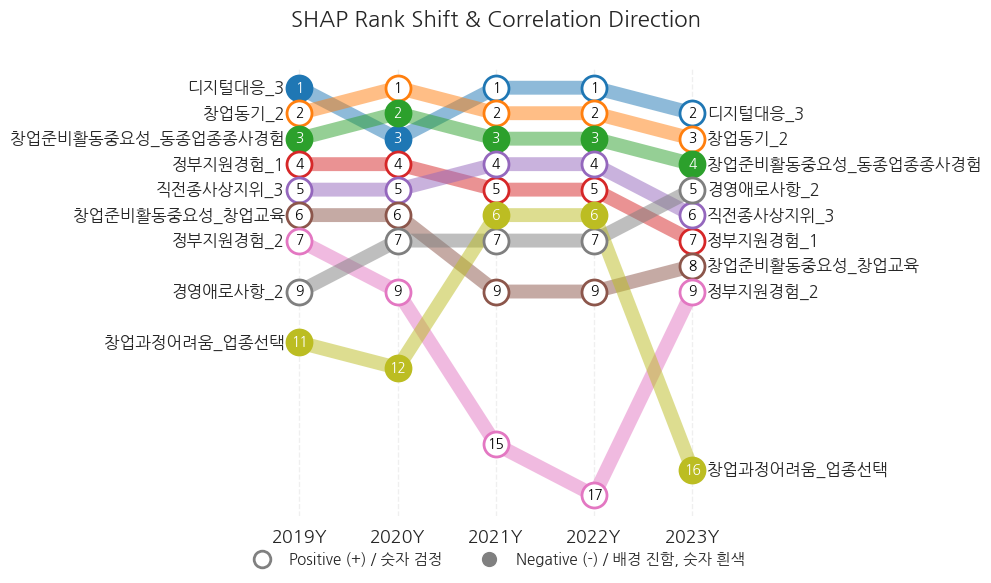


💡 [연도] 기준 하위 집단 간 방향성 이견(Discordance) 리포트 (Test Set)

▶ Correlation (CORR) 기준 엇갈리는 변수 (10개):
  - 디지털대응_3
  - 창업과정어려움_행정절차
  - 창업과정어려움_인력확보
  - 창업준비활동중요성_사업계획서작성
  - 디지털대응_응답여부
  - 창업과정어려움_자금조달
  - 경영애로사항_9
  - 디지털대응_6
  - 디지털대응_5
  - 디지털대응_4
▶ Quantile Regression (QR) 기준 엇갈리는 변수 (7개):
  - 창업과정어려움_업종선택
  - 창업과정어려움_행정절차
  - 창업준비활동중요성_시장조사
  - 총종사자
  - 부채현황
  - 디지털대응_2
  - 디지털대응_1

마스터 테이블이 저장되었습니다: /mnt/c/DataScience/[DIVE]/Brand/KTY/Result/FeatureImportance_MasterTable_Test_LightGBM_연도.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [8]:
# 연도
target_group = '연도'
groups = {'2019Y': 2019, '2020Y': 2020, '2021Y': 2021, '2022Y': 2022, '2023Y': 2023}
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness = evaluation_class_GroupFairness(
    best_model=best_model,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
    scaler_dict=scaler
)

df_comparison = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_train=X_train, X_test=X_test,
    X_colname=X_colname,
    scaler_dict=scaler,
    best_algo=best_algo,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

# **`주의사항`**

- 이론적 근거가 교재 내용과 일치하지 않거나 누락될 경우, `해당 단계의 실습 점수는 반영되지 않습니다.`
- 또한, 각 셀의 문항당 `처음 보는 사람도 이해하기 쉽도록 간결하게 작성`해야 하며 `과도하고 방대한 내용이나 이해하기 어려운 경우 점수는 반영되지 않습니다.`

# **Problem:** 

(1) 비즈니스 문제 정의 및 목표 설정 (정성적)
- 교재 참고: `3장 인간중심 AI 의사결정: 빅데이터와 AI로 재편된 의사결정(p.61)`, `3.2 빅데이터와 AI가 실패한 것이 아니라 질문이 없었다(p.72)`, `3.3 성공적 AI 의사결정 본질: 문제정의, 데이터 기획, 설득(p.81)`
> - 아래 표의 `비즈니스 문제 대상 데이터`의 비즈니스 목적을 보고 `관심있는 데이터`를 선택과 이유 작성
> - 선택한 데이터로 `해결하고자 하는 현실 문제`를 한 문장으로 정의하여 `어떤 의사결정`을 내리고 싶은지 작성하고 `변경이 여러번 되었다면 변경된 과정들`도 포함 
> - 해당 의사결정이 성공 여부를 결정하기 위해 `분석 과정에서 어떤 목표가 설정`되어야 하는지 작성하고, 목표가 달성된다면 분석 결과가 `실제 어떤 비즈니스 의사결정`에 기여할 수 있는지 작성

| **분야** | **비즈니스 목적** | **파일명** | **설명 참고링크** |
|:---:|:---|:---|:---|
| **Tour** | 고객들의 여행취소를 정확하게 예측하여   취소가 예상되는 고객을 찾고 기업의 매출손실 대비 | `Classification_TravelCustomerChurn.csv` | https://www.kaggle.com/datasets/tejashvi14/tour-travels-customer-churn-prediction |
| **Marketing** | 마케팅이 구매로 이어지는 관계를   정확하게 예측 및 특성을 확인하여 마케팅 효과를 높이고 매출 향상 지원 | `Classification_MarketingEfficiency.csv` | https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign |
| **Human** | 기업 임직원들의 불만족을 정확하게   예측하여 퇴사 확률을 낮출 수 있는 인사전략 지원 | `Classification_JobSatisfaction.csv` | https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction |
| **Medicine** | 심장질환 여부를 정확하게 예측하여   심장질환에 걸릴 가능성이 높은 고객의 특징을 예측 | `Classification_HeartDisease.csv` | https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression |
| **Ecommerce** | 이커머스 만족도를 정확하게 예측하여   만족도 향상을 위한 특성을 확인하고 고객 유입 전략 지원 | `Classification_EcommerceSatisfaction.csv` | https://www.kaggle.com/datasets/prachi13/customer-analytics |
| **Service** | 항공기를 이용하는 고객의 서비스   만족도를 정확하게 예측하여 특성을 확인하고 추가적인 서비스기획 지원 | `Classification_AirlineSatisfaction.csv` | https://www.kaggle.com/datasets/sjleshrac/airlines-customer-satisfaction |

> - 모든 데이터는 [Kaggle Competition](https://www.kaggle.com/)에서 추출되었으며, `현 Jupyter Notebook`과 동일위치 `DataTest 폴더`에 있음
> - 원본은 링크의 데이터이지만, 실제 과제에 사용 데이터는 `반드시 원본이 일부 변경되어 저장된 DataTest 내 데이터만` 사용!
> - 분석은 `개인PC나 Google Colab` 중 편한 곳에서 진행하면 되며, 향후 `경진대회나 공모전 및 데이터사이언스 분야 면접이나 시험`에 대비 가능

---

(2) 분석 전 인간의 통찰과 가설 (정성적)
- 교재 참고: `2.1 인간을 대신하는 학습과 예측의 원리(p.30)`, `2.3 알고리즘의 진화: 인간적 데이터해석에서 기계적 패턴 학습의 여정(p.37)`
> - AI 의사결정 분석을 시작하기 전, 비즈니스 목적만 보았을때 여러분이 바라는 데이터에 포함되었으면 하는 `종속변수(Y)`와 `독립변수(X)` 후보들을 작성
> - `본인의 직관이나 도메인 지식 기반` 종속변수와 독립변수 후보들로 `어떤 의사결정 가설을 해결하고 싶은지 최소 3개 이상` 작성

---

(3) 데이터 구조화: $Y = f(X)$ 프레임워크 (정량적)
- 교재 참고: `3.1 데이터는 기계가 읽고, 의미는 인간이 만든다(p.64)`, `3.3 성공적 AI 의사결정 본질: 문제정의, 데이터 기획, 설득(p.81)`
> - 본인이 작성한 가설들을 `실제 데이터로써 반영할 수 있는지 확인`하는 과정으로,
> - 데이터를 불러온(Data Loading) 후 특성을 확인하며, `각 의사결정 가설 별 어떤 종속변수와 독립변수를 사용` 할 수 있을지 작성 
> - `나의 통찰과 데이터 근거`를 기반으로 최종적으로 활용가능한 `나의 데이터 의사결정 가설 1개`를 작성하고, 데이터 통계량과 시각화 등의 데이터 탐색을 통해 `어떤 변수들이 영향을 줄 것으로 예상`되는지 작성 (ex. 소득 수준($X1$)이 높을수록 소비 금액($Y$)이 높을 것이다.)
> - Q. `교재 p.81~82` 참고할 때, (A) 현실의 `비즈니스 문제를 데이터 문제($Y=f(X)$)로 변환하는 과정이 의미하는 바`가 무엇인지 교재의 표현을 빌려 서술하고, (B) 본인이 선택한 Y와 X가 `해당 비즈니스 목적을 달성하는 데 어떻게 기여할 수 있는지` 작성

# **Applying Algorithms:** Logistic Regression, Ramdom Forest, XGBoost

- 단순히 정확성이 높은 모델을 찾는 것이 아니라, `왜 그런 예측이 나왔는가?`를 이해하는 것이 AI 의사결정의 핵심입니다.

---

**1)** `preprocessing_ME` 전처리 데이터에 `Logistic Regression 알고리즘을` 사용하여 `학습 및 예측` 진행

- 교재 참고: `3.3 성공적 AI 의사결정 본질: 문제 정의, 데이터 기획, 설득(p.81,101)`, `4.1 인간과 기계, 서로 다른 강점으로 현실을 바꾸는 협업 해법(p.108)`
- Train & Test 모두에 대해 `학습 및 예측`

---

**2)** `Train & Test 모두의 검증지표를 통해 성능`을 확인

- 교재 참고: `4.1 인간과 기계, 서로 다른 강점으로 현실을 바꾸는 협업 해법(p.108)`
- Train & Test 예측 성능 확인을 위한 `5개의 검증지표`를 표로 출력
> (1) Accuracy     
> (2) Precision     
> (3) Recall/Sensitivity/TPR     
> (4) F1-score     
> (5) AuC 
- AuC는 실제 Threshold가 변경될 때마다 `어떻게 성능이 변하는지 시각화(반드시 강의자료 내 evaluation_class_ROCAUC 함수 사용)` 출력
- Q. 본인의 비즈니스 문제에서 (A) `교재 표 2.3`을 참고할 때 단순히 통계적으로 과거 현상을 설명하는 것에 그치지 않고 기계학습 알고리즘으로 검증 성능을 높여야 하는 근본적인 이유를 교재의 관점에서 서술하고, (B) 본인이 실습에서 확인한 `검증 지표 결과가 비즈니스적으로 어떤 가치`를 지니는지 교재의 관점에서 설명함과 동시에 `본인의 비즈니스 문제 상 가장 신뢰할 만한 지표`는 무엇인지 작성

---

**3)** `preprocessing_GenAI` 전처리 데이터로 변경해서 `1) + 2)` 과정을 동일하게 모두 실행 및 결과 작성

---

**4-1)** 향후 수업에서 배우게 될 `대표적 머신러닝 알고리즘`을 사용하여 `1) + 2) + 3)` 과정을 모두 실행 및 성능 비교

- 교재 참고: `4.2 우리는 뼈대(프로세스)를 세우고, 기계는 살(기술)을 붙인다(p.119)`, `5.2 AI가 답을 주는 순간, 인간은 질문을 시작한다(p.156)`
- 앞선 결과에서 `preprocessing_ME`와 `preprocessing_GenAI` 중 예측 성능이 높았던 함수로 전처리 진행
- `Random Forest` 알고리즘의 학습 및 예측 부분은 생성형 AI에게 `어떻게 프롬프트로 지시했는지` 작성 하고 `생성된 모델링 코드를 활용`
- `Random Forest` 알고리즘을 사용해서 `Train & Test`의 `기존 검증지표`를 통해 로지스틱회귀분석 대비 과거와 미래 재현성 관점에서 성능이 어떤지 주석으로 작성

---

**4-2)** 향후 수업에서 배우게 될 `대표적 머신러닝 알고리즘`을 사용하여 `1) + 2) + 3)` 과정을 모두 실행 및 성능 비교

- 교재 참고: `4.2 우리는 뼈대(프로세스)를 세우고, 기계는 살(기술)을 붙인다(p.119)`, `5.2 AI가 답을 주는 순간, 인간은 질문을 시작한다(p.156)`
- 앞선 결과에서 `preprocessing_ME`와 `preprocessing_GenAI` 중 예측 성능이 높았던 함수로 전처리 진행
- `XGBoost` 알고리즘의 학습 및 예측 부분은 생성형 AI에게 `어떻게 프롬프트로 지시했는지` 작성 하고 `생성된 모델링 코드를 활용`
- `XGBoost` 알고리즘을 사용해서 `Train & Test`의 `기존 검증지표`를 통해 로지스틱회귀분석 대비 과거와 미래 재현성 관점에서 성능이 어떤지 주석으로 작성

---

**5)** 모델링 방향 정리

- `검증지표`를 기준으로 `Train & Test` 각각에 대해 3가지 알고리즘 중 `어떤 알고리즘이 과거와 미래의 재현성에서 우수한지` 주석으로 작성
- 실제 비즈니스에 활용하기 위해선 `Train & Test` 중 `어떤 데이터의 예측력이 더욱 중요한지 + 최종 활용 알고리즘` 주석으로 작성

## **1)** `preprocessing_ME` 전처리 데이터에 `Logistic Regression 알고리즘을` 사용하여 `학습 및 예측` 진행

- 교재 참고: `3.3 성공적 AI 의사결정 본질: 문제 정의, 데이터 기획, 설득(p.81,101)`, `4.1 인간과 기계, 서로 다른 강점으로 현실을 바꾸는 협업 해법(p.108)`
- Train & Test 모두에 대해 `학습 및 예측`

In [ ]:
# preprocessing_ME의 출력 변수명 주석으로 작성



In [ ]:
# Train & Test 모두에 대해 `학습 및 예측`



## **2)** `Train & Test 모두의 검증지표를 통해 성능`을 확인

- 교재 참고: `4.1 인간과 기계, 서로 다른 강점으로 현실을 바꾸는 협업 해법(p.108)`
- Train & Test 예측 성능 확인을 위한 `5개의 검증지표`를 표로 출력
> (1) Accuracy     
> (2) Precision     
> (3) Recall/Sensitivity/TPR     
> (4) F1-score     
> (5) AuC     
- AuC는 실제 Threshold가 변경될 때마다 `어떻게 성능이 변하는지 시각화(반드시 강의자료 내 evaluation_class_ROCAUC 함수 사용)` 출력
- Q. 본인의 비즈니스 문제에서 (A) `교재 표 2.3`을 참고할 때 단순히 통계적으로 과거 현상을 설명하는 것에 그치지 않고 기계학습 알고리즘으로 검증 성능을 높여야 하는 근본적인 이유를 교재의 관점에서 서술하고, (B) 본인이 실습에서 확인한 `검증 지표 결과가 비즈니스적으로 어떤 가치`를 지니는지 교재의 관점에서 설명함과 동시에 `본인의 비즈니스 문제 상 가장 신뢰할 만한 지표`는 무엇인지 작성

In [ ]:
# Train & Test 예측 성능 확인을 위한 `5개의 검증지표`를 표로 출력
# (1) Accuracy     
# (2) Precision     
# (3) Recall/Sensitivity/TPR     
# (4) F1-score     
# (5) AuC    
# AuC는 실제 Threshold가 변경될 때마다 `어떻게 성능이 변하는지 시각화(반드시 강의자료 내 evaluation_class_ROCAUC 함수 사용)` 출력



In [ ]:
# Q. 본인의 비즈니스 문제에서 
# (A) `교재 표 2.3`을 참고할 때 단순히 통계적으로 과거 현상을 설명하는 것에 그치지 않고 기계학습 알고리즘으로 검증 성능을 높여야 하는 근본적인 이유를 교재의 관점에서 서술하고, 
# (B) 본인이 실습에서 확인한 `검증 지표 결과가 비즈니스적으로 어떤 가치`를 지니는지 교재의 관점에서 설명함과 동시에 `본인의 비즈니스 문제 상 가장 신뢰할 만한 지표`는 무엇인지 작성



## **3)** `preprocessing_GenAI` 전처리 데이터로 변경해서 `1) + 2)` 과정을 동일하게 모두 실행 및 결과 작성

In [ ]:
# preprocessing_ME의 출력 변수명 주석으로 작성



In [ ]:
# Train & Test 모두에 대해 `학습 및 예측`



In [ ]:
# Train & Test 예측 성능 확인을 위한 `5개의 검증지표`를 표로 출력
# (1) Accuracy     
# (2) Precision     
# (3) Recall/Sensitivity/TPR     
# (4) F1-score     
# (5) AuC    
# AuC는 실제 Threshold가 변경될 때마다 `어떻게 성능이 변하는지 시각화(반드시 강의자료 내 valuation_class_ROCAUC 함수 사용)` 출력



In [ ]:
# Preprocessing_ME 함수와 Preprocessing_GenAI 함수 중 어떤 전처리가 모델링의 Test 예측력을 높이는지 주석으로 작성
# (ex. Test 기준 Preprocessing_ME는 3개 지표 1위 & Preprocessing_GenAI는 2개 지표 1위 -> Preprocessing_ME 선택!)



## **4-1)** 향후 수업에서 배우게 될 `대표적 머신러닝 알고리즘`을 사용하여 `1) + 2) + 3)` 과정을 모두 실행 및 성능 비교

- 교재 참고: `4.2 우리는 뼈대(프로세스)를 세우고, 기계는 살(기술)을 붙인다(p.119)`, `5.2 AI가 답을 주는 순간, 인간은 질문을 시작한다(p.156)`
- 앞선 결과에서 `preprocessing_ME`와 `preprocessing_GenAI` 중 예측 성능이 높았던 함수로 데이터 로딩 후 전처리 진행
- `Random Forest` 알고리즘의 학습 및 예측 부분은 생성형 AI에게 `어떻게 프롬프트로 지시했는지` 작성 하고 `생성된 모델링 코드를 활용`하여 데이터 로딩 -> 전처리 -> 모델링 -> 성능확인(시각화+검증지표) 등 진행
- `Random Forest` 알고리즘을 사용해서 `Train & Test`의 `기존 검증지표`를 통해 로지스틱회귀분석 대비 과거와 미래 재현성 관점에서 성능이 어떤지 주석으로 작성

In [ ]:
# 앞선 결과에서 `preprocessing_ME`와 `preprocessing_GenAI` 중 
# Test 예측 성능이 높았던 함수로 데이터 로딩 후 전처리 진행



In [ ]:
# `Random Forest` 알고리즘의 학습 및 예측 부분은 생성형 AI에게 `어떻게 프롬프트로 지시했는지` 작성 



In [ ]:
# `생성된 모델링 코드를 활용`하여 데이터 로딩 -> 전처리 -> 모델링 -> 성능확인(시각화+검증지표) 등 진행



In [ ]:
# `Random Forest` 알고리즘을 사용해서 `Train & Test`의 `기존 검증지표`를 통해 로지스틱회귀분석 대비 과거와 미래 재현성 관점에서 성능이 어떤지 주석으로 작성



## **4-2)** 향후 수업에서 배우게 될 `대표적 머신러닝 알고리즘`을 사용하여 `1) + 2) + 3)` 과정을 모두 실행 및 성능 비교

- 교재 참고: `4.2 우리는 뼈대(프로세스)를 세우고, 기계는 살(기술)을 붙인다(p.119)`, `5.2 AI가 답을 주는 순간, 인간은 질문을 시작한다(p.156)`
- 앞선 결과에서 `preprocessing_ME`와 `preprocessing_GenAI` 중 예측 성능이 높았던 함수로 데이터 로딩 후 전처리 진행
- `XGBoost` 알고리즘의 학습 및 예측 부분은 생성형 AI에게 `어떻게 프롬프트로 지시했는지` 작성 하고 `생성된 모델링 코드를 활용`하여 데이터 로딩 -> 전처리 -> 모델링 -> 성능확인(시각화+검증지표) 등 진행
- `XGBoost` 알고리즘을 사용해서 `Train & Test`의 `기존 검증지표`를 통해 로지스틱회귀분석 대비 과거와 미래 재현성 관점에서 성능이 어떤지 주석으로 작성

In [ ]:
# 앞선 결과에서 `preprocessing_ME`와 `preprocessing_GenAI` 중 
# Test 예측 성능이 높았던 함수로 데이터 로딩 후 전처리 진행



In [ ]:
# `XGBoost` 알고리즘의 학습 및 예측 부분은 생성형 AI에게 `어떻게 프롬프트로 지시했는지` 작성



In [ ]:
# `생성된 모델링 코드를 활용`하여 데이터 로딩 -> 전처리 -> 모델링 -> 성능확인(시각화+검증지표) 등 진행



In [ ]:
# `XGBoost` 알고리즘을 사용해서 `Train & Test`의 `기존 검증지표`를 통해 로지스틱회귀분석 대비 과거와 미래 재현성 관점에서 성능이 어떤지 주석으로 작성



## **5)** 모델링 방향 정리

- `검증지표`를 기준으로 `Train & Test` 각각에 대해 3가지 알고리즘 중 `어떤 알고리즘이 과거와 미래의 재현성에서 우수한지` 주석으로 작성
- 실제 비즈니스에 활용하기 위해선 `Train & Test` 중 `어떤 데이터의 예측력이 더욱 중요한지 + 최종 활용 알고리즘` 주석으로 작성

In [ ]:
# 3가지 알고리즘의 각 이름과 검증지표를 출력



In [ ]:
# `검증지표`를 기준으로 `Train & Test` 각각에 대해 3가지 알고리즘 중 `어떤 알고리즘이 과거와 미래의 재현성에서 우수한지` 주석으로 작성



In [ ]:
# 실제 비즈니스에 활용하기 위해선 `Train & Test` 중 `어떤 데이터의 예측력이 더욱 중요한지 + 최종 활용 알고리즘` 주석으로 작성



# **Explanation:** 실제 과거 재현성 높은 이유를 설명하고 미래 설명 근거 제시

- 과제 초반에 세웠던 `인간의 가설`이 데이터로 증명되었는지 확인하는 과정입니다.

---

**1) `Train Explanation:`** 과거 재현 설명력

- 교재 참고: `4장 AI 시대의 협업: 질문하는 인간, 답하는 기계(p.105)`, `4.1 인간과 기계, 서로 다른 강점으로 현실을 바꾸는 협업 해법(p.108)`, `5장 AI 의사결정 실습: 정답은 AI가, 해답은 인간이(p.143)`
> (1) Logistic Regresion 기준,
> - 앞서 학습해둔 모델링 변수명을 그대로 사용해서 `summary 함수 결과`를 출력(재학습 아님)
> - 추정된 계수(Coef.)의 `odds ratio`를 계산한 후 `1을 예측하는데 긍정적(최대 5종) 및 부정적(최대 5종) 영향을 미치는 변수의 이름과 근거`를 주석으로 작성 

> (2) Random Forest & XGBoost 중,
> - Train 검증지표 성능이 가장 높았던 알고리즘의 `SHAP Summary Plot`을 시각화 한 후,
> - 종속변수에 `긍정적/부정적 영향을 주는 상위 5개(총 10종)의 변수 이름`을 시각화를 기반 주석으로 작성
> - (설명가능한 인공지능 중 하나인 SHAP는 수업에서 직접적으로 다루지 않으나 아래 설명과 관련 지식을 스스로 습득하여 진행)

> (3) `종속변수에 영향을 주는 변수들` 정리
> - 아래의 표와 같이 최종적으로 각 변수가 종속변수에 어떻게 영향을 주는지 `표로 작성`하고
> - (Markdown 표 형식을 사용하거나 이미지로 캡처하여 첨부)
>
> |  |  | **[Train] Linear Regression** |  |
> |---|---|:---:|:---:|
> |  |  | **Positive Effect** | **Negative Effect** |
> | **[Train] RF or XGBoost** | **Positive Effect** | A, B, C | D, E |
> |  | **Negative Effect** | H, I | F, G |
>
> - 본인이 세웠던 `인간의 가설과 얼마나 일치하는지 그리고 일치하지 않는다면 그 이유는 무엇이고 어떤 결정을 내려야 한다고 생각하는지` 주석으로 작성

---

**2) `Test Explanation:`** 미래 재현 설명력

- 교재 참고: `4장 AI 시대의 협업: 질문하는 인간, 답하는 기계(p.105)`, `4.3 질문이 권력이다: AI는 답을 준다, 인간은 의미를 만든다(p.125)`, `5장 AI 의사결정 실습: 정답은 AI가, 해답은 인간이(p.143)`
> (1) Random Forest & XGBoost 중,
> - Test 검증지표 성능이 가장 높았던 알고리즘의 `SHAP Summary Plot`을 시각화 한 후,
> - 종속변수에 `긍정적/부정적 영향을 주는 상위 5개(총 10종)의 변수 이름`을 시각화를 기반 주석으로 작성

> (2) `종속변수에 영향을 주는 변수들` 정리
> - 아래의 표와 같이 최종적으로 각 변수가 종속변수에 어떻게 `과거와 미래에` 영향을 주는지 `표로 작성`하고
> - (Markdown 표 형식을 사용하거나 이미지로 캡처하여 첨부)
>
> |  |  | **[Train] Linear   Regression or RF or XGBoost** |  |
> |---|---|:---:|:---:|
> |  |  | **Positive Effect** | **Negative Effect** |
> | **[Test] Linear Regression or RF or XGBoost** | **Positive Effect** | A, B, C | D, E |
> |  | **Negative Effect** | H, I | F, G |
>
> - 과거에 긍정/부정으로 영향을 주던 변수들이 `미래에는 어떻게 변화되는지 주석으로 작성`하되
> - (예. 과거에도 특정 변수가 종속변수에 영향을 주는 경향이 미래에는 블라블라한 확률로~~, 미래에는 종속변수에 블라블라 영향을 줄수 있으며 그 근거는 블라블라~)
> - 변화없이 동일하다면 `그 이유는 무엇`인지, 또는 변화된다면 `그 이유는 무엇`이라고 생각하는지 반드시 포함하여 주석으로 작성

---

**3) `최종 의사결정` 제언**

- 교재 참고: `4.3 질문이 권력이다: AI는 답을 준다, 인간은 의미를 만든다(p.125)`, `5.1 뼈대가 성패를 가른다: 성공과 실패를 가르는 AI 의사결정 공식(p.146)`
> - Q. 본 교재의 제목이자 핵심 철학인 `결정은 우리가, 분석은 기계가`에 비추어 볼 때, (A) AI의 모델링(분석)이 끝난 후 최종 비즈니스 전략(결정)을 수립하는 과정에서 `인간(의사결정자)이 반드시 개입해야 하는 이유`는 무엇인지 교재의 머리말에 명시된 AI 의사결정의 궁극적인 목적을 인용하고, (B) 본인의 실습 결과를 `어떻게 비즈니스 현장에 적용할 것`인지 주석으로 작성
> - [분석 과정] 가장 성능이 좋은 모델을 선택하는 것을 넘어, `이러한 AI 의사결정 과정이 실제 비즈니스 현장에서 어떻게 활용하면 될지` 주석으로 작성
> - [결과 활용] 분석 결과 전달 프로세스를 참고하여 여러분의 `분석 결과를 의사결정권자에게 전달/설득할 최종적 비즈니스 전략`을 주석으로 작성
> - Q. 본인의 모델링 분석 결과(중요 변수, 예측값 등)가 도출되었고 AI가 훌륭한 분석 답안을 내놓았음에도 불구하고, 그 `결과를 맹신하지 않고 인간이 비즈니스 맥락에 맞춰 최종 결정을 주도해야 하는 이유`는 무엇인지 `교재 마지막 부분의 끝나지 않는 여정`에 나오는 문구를 인용하여 본인의 생각을 주석으로 작성

## [참고] **XAI(eXplainable AI):** 설명가능한 인공지능

**1) SHAP(SHapley Additive exPlanations) 알고리즘 배경:** 설명 가능한 AI를 위한 방법론

- **AI 블랙박스 이슈:** 많은 AI 모델(특히 딥러닝, 랜덤 포레스트, XGBoost 등)은 예측 성능이 뛰어나지만, 내부 동작을 이해하거나 해석하기 어려운 `블랙박스 모델로 간주`

<center><img src='Image/Advanced/Blackbox_vs_Whitebox.webp' width='600'>(https://liquidity-provider.com/articles/demystifying-black-box-ai-and-its-use-cases/)</center>

> - 모델들이 어떻게 결정을 내리는지 이해하지 못하면, `AI의 신뢰성이나 공정성을 평가하기 어려움`
> - 특히 `의료, 금융, 법률 등 중요한 분야일수록 그 문제가 더욱 중요`하며 해결 필요성이 높음
> - SHAP은 `게임 이론에서 유래한 Shapley 값을 기반`으로 `각 변수가 모델의 예측에 미친 영향을 정량적으로 설명`
> - SHAP는 `2017년에 Scott Lundberg & Su-In Lee에 의해 소개`

---

**2) 필요성:**

<center><img src='Image/Advanced/Blackbox_vs_Whitebox_Example.webp' width='600'>(https://www.analyticsvidhya.com/blog/2019/08/decoding-black-box-step-by-step-guide-interpretable-machine-learning-models-python/)</center>

**(1) 모델 해석 가능성 제공:** 예측을 할 때 `각 변수(Feature)가 얼마나 영향력이 큰지를 시각화`하여 결정 과정을 명확하게 설명

**(2) 모델 공정성 검토:** 특정 특성(예: 성별, 나이 등)이 얼마나 예측에 영향을 미쳤는지 분석 함으로써 `모델의 편향과 공정성 여부를 파악`

**(3) 신뢰성 향상:** 사용자는 모델의 예측이 `왜 그런 결과를 도출했는지 이해할 수 있기에 신뢰도가 높아짐`

---

**3) 특징 및 세부기능:**

- **특징**

> - Shapley 값은 게임 이론에서 유래된 개념으로, `각 참여자가 게임에서 얻은 총 이익을 공정하게 분배하는 방법`
> - AI에서 Shapley 값은 `각 변수가 모델 예측에 기여하는 정도`를 정의하는 데 사용
> - Shapley 값은 `모든 가능한 변수 조합에 대해 각 변수가 예측에 미친 영향을 계산`
> - **Local(Individual) Explanation:** 변수 뿐만 아니라 `각 고객별(Sample) 변수들의 기여도로 개별 예측 설명` 유용
> - **Global(Total) Explanation:** 고객별 개별 예측 설명을 합산하여 `전체 데이터셋에서 변수들의 모델 예측 영향을 설명`

- **세부기능:**

> **(1) Decison & Force Plot:** `개별 예측`을 이끌어낸 `변수들의 SHAP 기여도를 직관적 시각화`
>
> <center><img src='Image/Advanced/SHAP_Decisionplot.webp' width='600'></center>
> <center><img src='Image/Advanced/SHAP_Text.png' width='600'></center>
>
> **(2) Dependence Plot:** `전체 예측`을 이끌어낸 `각 변수의 실제 값과 SHAP 예측치의 관계`를 시각화
> 
> <center><img src='Image/Advanced/SHAP_Dependenceplot.webp' width='600'></center>
>
> **(3) Summary Plot:** 각 변수가 모델 `전체 예측`에 미친 기여 영향력을 한눈에 분포로 시각화`
>
> <center><img src='Image/Advanced/SHAP_Heatmap.webp' width='600'></center>
> <center><img src='Image/Advanced/SHAP_Beeswarm.webp' width='600'>(https://shap.readthedocs.io/en/latest/index.html)</center>
>
> | **구분** | **Decision Plot** | **Summary Plot** |
> |:---:|:---:|:---:|
> | **대상** | **개별 샘플** | **전체 데이터** |
> | **해석방법** | **> X축:** 변수의 예측 기여 SHAP 값<br>**> Y축:** 변수 중요도 내림차순 기반 누적 기여 SHAP값<br>**> 선그래프:** 기울기 기반 해당 변수 영향력 <br>(기울기 변화가 클수록 예측에 크게 기여하기에 위로 갈수록 중요) | **> X축:** 변수의 예측 기여 SHAP 값<br>**> Y축:** 변수 중요도 내림차순 기반 변수별 샘플기여 누적 SHAP 값<br>**> 분포선그래프:** 변수 값의 변화에 따른 예측 기여 방향과 정도<br>- **파란색:** 변수의 낮은값에 대한 SHAP 값 분포<br>- **빨간색:** 변수의 높은값에 대한 SHAP 값 분포<br>- **파란색->빨간색 분포변화:** 예측에 대한 긍정기여<br>- **빨간색->파란색 분포변화:** 예측에 대한 부정기여<br>(분포 변화가 클수록 예측에 크게 기여하기에 위로 갈수록 중요 변수) |
> | **설명** | 개별 예측의 결정 경로를 누적 SHAP 값으로 시각화<br>(선 = 개별기여, 변수 = 결정경로 우선순위) | 개별 예측의 변수별 기여방향을 누적하여 SHAP 값 분포로 시각화<br>(점 = 개별기여, 색 = 기여방향, 변수 = 전체결정 우선순위)  |
> | **활용목적** | 개별 예측의 주요변수 식별과 결정과정 추적<br>샘플 결과간 비교를 통한 개별 샘플의 인싸이트 확보 | 전체 예측의 주요변수 식별과 영향방향 해석<br>모델의 전반적인 이해로 의사결정 지원 |


---

**4) 요약:**

- SHAP는 `AI 모델의 예측을 투명하게 설명하는 현존하는 강력한 도구`
- SHAP 값을 통해 모델의 `예측을 직관적으로 이해하고, 모델의 공정성, 신뢰성, 투명성을 개선`
- SHAP는 설명 가능한 AI의 핵심 기술로 자리잡고 있으며, `다양한 분야에서 실용적으로 활용`

## **1) `Train Explanation:`** 과거 재현 설명력

- 교재 참고: `4장 AI 시대의 협업: 질문하는 인간, 답하는 기계(p.105)`, `4.1 인간과 기계, 서로 다른 강점으로 현실을 바꾸는 협업 해법(p.108)`, `5장 AI 의사결정 실습: 정답은 AI가, 해답은 인간이(p.143)`
> (1) Logistic Regresion 기준,
> - 앞서 학습해둔 모델링 변수명을 그대로 사용해서 `summary 함수 결과`를 출력(재학습 아님)
> - 추정된 계수(Coef.)의 `odds ratio`를 계산한 후 `1을 예측하는데 긍정적(최대 5종) 및 부정적(최대 5종) 영향을 미치는 변수의 이름과 근거`를 주석으로 작성 

> (2) Random Forest & XGBoost 중,
> - Train 검증지표 성능이 가장 높았던 알고리즘의 `SHAP Summary Plot`을 시각화 한 후,
> - 종속변수에 `긍정적/부정적 영향을 주는 상위 5개(총 10종)의 변수 이름`을 시각화를 기반 주석으로 작성
> - (설명가능한 인공지능 중 하나인 SHAP는 수업에서 직접적으로 다루지 않으나 아래 설명과 관련 지식을 스스로 습득하여 진행)

> (3) `종속변수에 영향을 주는 변수들` 정리
> - 아래의 표와 같이 최종적으로 각 변수가 종속변수에 어떻게 영향을 주는지 `표로 작성`하고
> - (Markdown 표 형식을 사용하거나 이미지로 캡처하여 첨부)
>
> |  |  | **[Train] Linear Regression** |  |
> |---|---|:---:|:---:|
> |  |  | **Positive Effect** | **Negative Effect** |
> | **[Train] RF or XGBoost** | **Positive Effect** | A, B, C | D, E |
> |  | **Negative Effect** | H, I | F, G |
>
> - 본인이 세웠던 `인간의 가설과 얼마나 일치하는지 그리고 일치하지 않는다면 그 이유는 무엇이고 어떤 결정을 내려야 한다고 생각하는지` 주석으로 작성

In [ ]:
# 3가지 알고리즘 중 Train 기준 가장 예측 성능이 높은 알고리즘 이름을 주석으로 작성



In [ ]:
# (1) Logistic Regresion 기준,
# - 앞서 학습해둔 모델링 변수명을 그대로 사용해서 `summary 함수 결과`를 출력(재학습 아님)
# - 추정된 계수(Coef.)의 `odds ratio`를 계산한 후 `1을 예측하는데 긍정적(최대 5종) 및 부정적(최대 5종) 영향을 미치는 변수의 이름과 근거`를 주석으로 작성 



In [ ]:
# (2) Random Forest & XGBoost 중,
# - Train 검증지표 성능이 가장 높았던 알고리즘의 `SHAP Summary Plot`을 시각화 한 후,
# - 종속변수에 `긍정적/부정적 영향을 주는 상위 5개(총 10종)의 변수 이름`을 시각화를 기반 주석으로 작성
# - (설명가능한 인공지능 중 하나인 SHAP는 수업에서 직접적으로 다루지 않으나 아래 설명과 관련 지식을 스스로 습득하여 진행)



In [ ]:
# (3) `종속변수에 영향을 주는 변수들` 정리
# - 아래의 표와 같이 최종적으로 각 변수가 종속변수에 어떻게 영향을 주는지 `표로 작성`하고
# - (Markdown 표 형식을 사용하거나 이미지로 캡처하여 첨부)



|  |  | **[Train] Linear Regression** |  |
|---|---|:---:|:---:|
|  |  | **Positive Effect** | **Negative Effect** |
| **[Train] RF or XGBoost** | **Positive Effect** | A, B, C | D, E |
|  | **Negative Effect** | H, I | F, G |

In [ ]:
# 본인이 세웠던 `인간의 가설과 얼마나 일치하는지 그리고 일치하지 않는다면 그 이유는 무엇이고 어떤 결정을 내려야 한다고 생각하는지` 주석으로 작성



## **2) `Test Explanation:`** 미래 재현 설명력

- 교재 참고: `4장 AI 시대의 협업: 질문하는 인간, 답하는 기계(p.105)`, `4.3 질문이 권력이다: AI는 답을 준다, 인간은 의미를 만든다(p.125)`, `5장 AI 의사결정 실습: 정답은 AI가, 해답은 인간이(p.143)`
> (1) Random Forest & XGBoost 중,
> - Test 검증지표 성능이 가장 높았던 알고리즘의 `SHAP Summary Plot`을 시각화 한 후,
> - 종속변수에 `긍정적/부정적 영향을 주는 상위 5개(총 10종)의 변수 이름`을 시각화를 기반 주석으로 작성

> (2) `종속변수에 영향을 주는 변수들` 정리
> - 아래의 표와 같이 최종적으로 각 변수가 종속변수에 어떻게 `과거와 미래에` 영향을 주는지 `표로 작성`하고
> - (Markdown 표 형식을 사용하거나 이미지로 캡처하여 첨부)
>
> |  |  | **[Train] Linear   Regression or RF or XGBoost** |  |
> |---|---|:---:|:---:|
> |  |  | **Positive Effect** | **Negative Effect** |
> | **[Test] Linear Regression or RF or XGBoost** | **Positive Effect** | A, B, C | D, E |
> |  | **Negative Effect** | H, I | F, G |
>
> - 과거에 긍정/부정으로 영향을 주던 변수들이 `미래에는 어떻게 변화되는지 주석으로 작성`하되
> - (예. 과거에도 특정 변수가 종속변수에 영향을 주는 경향이 미래에는 블라블라한 확률로~~, 미래에는 종속변수에 블라블라 영향을 줄수 있으며 그 근거는 블라블라~)
> - 변화없이 동일하다면 `그 이유는 무엇`인지, 또는 변화된다면 `그 이유는 무엇`이라고 생각하는지 반드시 포함하여 주석으로 작성

In [ ]:
# 3가지 알고리즘 중 Test 기준 가장 예측 성능이 높은 알고리즘 이름을 주석으로 작성



In [ ]:
# (1) Random Forest & XGBoost 중,
# - Test 검증지표 성능이 가장 높았던 알고리즘의 `SHAP Summary Plot`을 시각화 한 후,
# - 종속변수에 `긍정적/부정적 영향을 주는 상위 5개(총 10종)의 변수 이름`을 시각화를 기반 주석으로 작성



In [ ]:
# (2) `종속변수에 영향을 주는 변수들` 정리
# - 아래의 표와 같이 최종적으로 각 변수가 종속변수에 어떻게 `과거와 미래에` 영향을 주는지 `표로 작성`하고
# - (Markdown 표 형식을 사용하거나 이미지로 캡처하여 첨부)



|  |  | **[Train] Linear   Regression or RF or XGBoost** |  |
|---|---|:---:|:---:|
|  |  | **Positive Effect** | **Negative Effect** |
| **[Test] Linear Regression or RF or XGBoost** | **Positive Effect** | A, B, C | D, E |
|  | **Negative Effect** | H, I | F, G |

In [ ]:
# 과거에 긍정/부정으로 영향을 주던 변수들이 `미래에는 어떻게 변화되는지 주석으로 작성`하되
# (예. 과거에도 특정 변수가 종속변수에 영향을 주는 경향이 미래에는 블라블라한 확률로~~, 미래에는 종속변수에 블라블라 영향을 줄수 있으며 그 근거는 블라블라~)
# - 변화없이 동일하다면 `그 이유는 무엇`인지, 또는 변화된다면 `그 이유는 무엇`이라고 생각하는지 반드시 포함하여 주석으로 작성



**3) `최종 의사결정` 제언**

- 교재 참고: `4.3 질문이 권력이다: AI는 답을 준다, 인간은 의미를 만든다(p.125)`, `5.1 뼈대가 성패를 가른다: 성공과 실패를 가르는 AI 의사결정 공식(p.146)`
> - Q. 본 교재의 제목이자 핵심 철학인 `결정은 우리가, 분석은 기계가`에 비추어 볼 때, (A) AI의 모델링(분석)이 끝난 후 최종 비즈니스 전략(결정)을 수립하는 과정에서 `인간(의사결정자)이 반드시 개입해야 하는 이유`는 무엇인지 교재의 머리말에 명시된 AI 의사결정의 궁극적인 목적을 인용하고, (B) 본인의 실습 결과를 `어떻게 비즈니스 현장에 적용할 것`인지 주석으로 작성
> - [결과 활용] 분석 결과 전달 프로세스를 참고하여 여러분의 `분석 결과를 의사결정권자에게 전달/설득할 최종적 비즈니스 전략`을 주석으로 작성
> - Q. 본인의 모델링 분석 결과(중요 변수, 예측값 등)가 도출되었고 AI가 훌륭한 분석 답안을 내놓았음에도 불구하고, 그 `결과를 맹신하지 않고 인간이 비즈니스 맥락에 맞춰 최종 결정을 주도해야 하는 이유`는 무엇인지 `교재 마지막 부분의 끝나지 않는 여정`에 나오는 문구를 인용하여 본인의 생각을 주석으로 작성

In [ ]:
# Q. 본 교재의 제목이자 핵심 철학인 `결정은 우리가, 분석은 기계가`에 비추어 볼 때, 
# (A) AI의 모델링(분석)이 끝난 후 최종 비즈니스 전략(결정)을 수립하는 과정에서 `인간(의사결정자)이 반드시 개입해야 하는 이유`는 무엇인지 교재의 머리말에 명시된 AI 의사결정의 궁극적인 목적을 인용하고, 
# (B) 본인의 실습 결과를 `어떻게 비즈니스 현장에 적용할 것`인지 주석으로 작성



In [ ]:
# [결과 활용] 분석 결과 전달 프로세스를 참고하여 여러분의 `분석 결과를 의사결정권자에게 전달/설득할 최종적 비즈니스 전략`을 주석으로 작성



In [ ]:
# Q. 본인의 모델링 분석 결과(중요 변수, 예측값 등)가 도출되었고 AI가 훌륭한 분석 답안을 내놓았음에도 불구하고, 그 `결과를 맹신하지 않고 인간이 비즈니스 맥락에 맞춰 최종 결정을 주도해야 하는 이유`는 무엇인지 `교재 마지막 부분의 끝나지 않는 여정`에 나오는 문구를 인용하여 본인의 생각을 주석으로 작성



# **Future Analysis:** 분석 성능 평가 및 종료 판단하기

- 정확성이 100%인 모델은 존재하지 않습니다. 중요한 것은 `분석 결과 신뢰성을 위해 우리가 놓친 추가적으로 해볼만 한 비즈니스/기술적 방향이 있는가`를 파악하는 것입니다.

---

**1) 개선 방향 제안(Next Action Plan):**

- 교재 참고: `3장 인간중심 AI 의사결정: 빅데이터와 AI로 재편된 의사결정(p.61)`, `4장 AI 시대의 협업: 질문하는 인간, 답하는 기계(p.105)`, `5장 AI 의사결정 실습: 정답은 AI가, 해답은 인간이(p.143)`
> - 현재의 한계를 극복하고 성능을 높이기 위해, `전처리상 결측치를 다르게 처리하거나 변수 추가/삭제 등 어떤 다른 전처리 방향을 통해 성능 향상을 기대` 할 수 있을지 주석으로 작성
> - `현재 데이터로는 해결 불가능한 한계점`은 무엇인지? `새로운 외부 데이터를 결합한다면 어떤 성능 향상을 기대` 할 수 있을지 주석으로 작성
> - 그 외에 모델링의 과거 재현성과 미래 정확성 성능을 높이기 위해 `어떤 분석 과정상의 방향`을 고려해 볼 수 있는지 주석으로 작성
> - 위에서 작성한 3가지를 모두 실행해보고 최종적으로 성능이 향상된 방법을 주석으로 작성하고 `1) 최종 전처리 코드 + 2) 최종 모델링 코드 + 3) 최종 Test 검증지표 출력` (단순한 본인 생각인지 그저 허황된 말 뿐인지 진짜 가능한 전략인지 근거 제시 과정)

In [ ]:
# 현재의 한계를 극복하고 성능을 높이기 위해, `전처리상 결측치를 다르게 처리하거나 변수 추가/삭제 등 어떤 다른 전처리 방향을 통해 성능 향상을 기대` 할 수 있을지 주석으로 작성



In [ ]:
# `현재 데이터로는 해결 불가능한 한계점`은 무엇인지? `새로운 외부 데이터를 결합한다면 어떤 성능 향상을 기대` 할 수 있을지 주석으로 작성



In [ ]:
# 그 외에 모델링의 과거 재현성과 미래 정확성 성능을 높이기 위해 `어떤 분석 과정상의 방향`을 고려해 볼 수 있는지 주석으로 작성



In [ ]:
# 위에서 작성한 3가지를 모두 실행해보고 최종적으로 성능이 향상된 방법을 주석으로 작성하고 `1) 최종 전처리 코드 + 2) 최종 모델링 코드 + 3) 최종 Test 검증지표 출력`
# (단순한 본인 생각인지 그저 허황된 말 뿐인지 진짜 가능한 전략인지 근거 제시 과정)



In [35]:
### 종료 및 본인정보 반영
# 반드시 이 cell을 실행하시오
# 실행하지 않을 시 직접 하지 않은 것으로 간주
# 마지막 줄 출력으로 파일명을 설정하고 제출 필수
import platform, psutil, os, datetime
print(platform.processor())
print(str(round(psutil.virtual_memory().total / (1024.0 **3)))+"(GB)")
print(platform.system())
print(platform.version())
print(os.getcwd())
print(datetime.datetime.fromtimestamp(os.path.getctime(os.getcwd())))
print(datetime.datetime.fromtimestamp(os.path.getmtime(os.getcwd())))
print(datetime.datetime.fromtimestamp(os.path.getatime(os.getcwd())))
print(datetime.datetime.now())
title = 'DA_SupervisedClassification'    # 고정값
name = '김경원'    # 본인 이름을 작성
studentid = '20211011'    # 본인 학번을 작성
# 아래 강좌 명 중 본인이 수강하는 강과명 작성
# 비즈니스데이터사이언스이해, E정보시스템, 디지털비즈니스애널리틱스, E데이터베이스, 인공지능기반의사결정, 빅데이터 등
# 비즈니스혁신을위한데이터사이언스응용, 인공지능활용디지털경제플랫폼연구 등
course = '인공지능활용디지털경제플랫폼연구'    
print('다음 출력을 파일명으로 설정하고 제출하시오:', name + '_' + studentid + '_' + course + '_' + title)

Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
32(GB)
Windows
10.0.26100
C:\DataScience\Lecture\[DataScience]
2024-12-12 00:34:16.155373
2025-05-24 23:02:21.228873
2025-05-24 23:02:21.228873
2025-05-24 23:02:33.441233
다음 출력을 파일명으로 설정하고 제출하시오: 김경원_20211011_인공지능활용디지털경제플랫폼연구_DA_SupervisedClassification
